# 6-21-2023
## FFT Wave Analysis Practice to Prep for Simone's Special Spectral Analysis Methods
### Hector Salinas
-------
* (3-25-2026) This notebook serves as a testing hub for understanding the fundamentals of Fourier Analysis and the literal testing grounds for the statistical/performance analysis of the Python aMTM Periodicity Detector package as described in the published paper
    * (Since I'm adding these update notes now) Last official coding changes was on 9-1-2025

In [1]:
%matplotlib inline
import matplotlib
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from scipy import optimize 
from scipy.signal import find_peaks #displaying peaks on data
from scipy import signal
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from multitaper import MTSpec, MTCross, MTSine, SineCross
import multitaper.utils as utils
from matplotlib.gridspec import GridSpec


import matplotlib.cm as cm
import numpy as np
import math as mat
import random
#from scipy.fftpack import fft, ifft #Fourier Transform features
from scipy.fft import fft, ifft, irfft, rfft

import pandas as pd
import time


### Play Test 1: Converting Dummy Time Series to Frequency Domain
---
* (6-22-2023) From Nicki:
    * try making artificial time series and running them through FFT: pure sine wave, pure sine with different frequencies; pure sine wave with different amplitudes; two sine waves of different frequencies and amplitudes added together; a square wave; a step function; a straight line slowly increasing; then start playing with real data of whatever you want
* Helpful Links:
    * https://docs.scipy.org/doc/scipy/tutorial/fft.html
    * https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.04-FFT-in-Python.html
* Trig Reminders:
    * $y(t) = Asin(\omega t)$, where $\omega = 2\pi/T = 2\pi f$ 
        * To have plot full single period: y($t_{max}$) = sin($2\pi$) = 0 or f = 1/$t_{max}$
* Some FT jargon terms
    * T = $\Delta t \cdot$N = window length of time series (in seconds)
        * $\Delta$t = time step or sample interval = time between samples
            * Instrument sampling rate: $\Delta$s = 1/$\Delta$t 
        * N = number of datapoints in time series; also used for number of iterations for FFT summation
        * Sample (Rayleigh) Frequency $\Delta$f or $f_{ray} = 1/T = 1/(N\Delta t)$
        * Nyquist Frequency $f_{nyq}$ = 1/($\Delta t \cdot2$): highest possible frequency without introducing errors
* **Fourier Transform**: 
    * (Continuous Form): X($f_k) = \int_{0}^{T} x(t)e^{-i2\pi ft} dt$ $\rightarrow$ Discrete $\rightarrow$ X[k] = $\Sigma_{n=0}^{N-1}x[n]e^{-i2\pi(k\Delta f)(n\Delta t)}$
    * (Discrete Form 2): X[k or $\omega_k$] = $\Sigma_{n=0}^{N-1}x[n]e^{-i(2\pi k/N)n}$, where k,n = [0,N-1]
    * X[k]: Fourier coefficients from periodic sequence x[n]. 
        * Where x[n] = x[n+rN]. Alt def: equally spaced samples of Fourier transform of one period of x[n]
        * **Some texts** define N as the period of the signal
    * Radian Frequency Space/Axis of Fourier transform, $\omega_k$ = (2$\pi$/N)k and $\omega_k:[0,2\pi]$
        
* Extra link reference for later:
    * https://en.wikipedia.org/wiki/Fast_Fourier_transform
    * https://en.wikipedia.org/wiki/Discrete_Fourier_transform
    * https://dsp.stackexchange.com/questions/30552/sampling-rate-vs-sampling-time-of-fft
* (6-26-2023) Links on creating noise:
    * https://www.codingdeeply.com/how-to-add-noise-to-your-dataset-in-python/?expand_article=1
    * https://stackoverflow.com/questions/32237769/defining-a-white-noise-process-in-python
* (6-30-2023)
    * Difference between Power Spectral Density and FFT Bin Amplitude:
        * https://dsp.stackexchange.com/questions/24780/power-spectral-density-vs-fft-bin-magnitude
        * PSD: $P(f_k) = |X(f_k)|^2 / N$
        * Periodogram: plot of spectral density vs. frequency
    

With dt = 0.0010, our sampling rate is 1000.00Hz
Number of dtps in our time series is 10000000.00
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz
Nyquist Freq = 500.00Hz


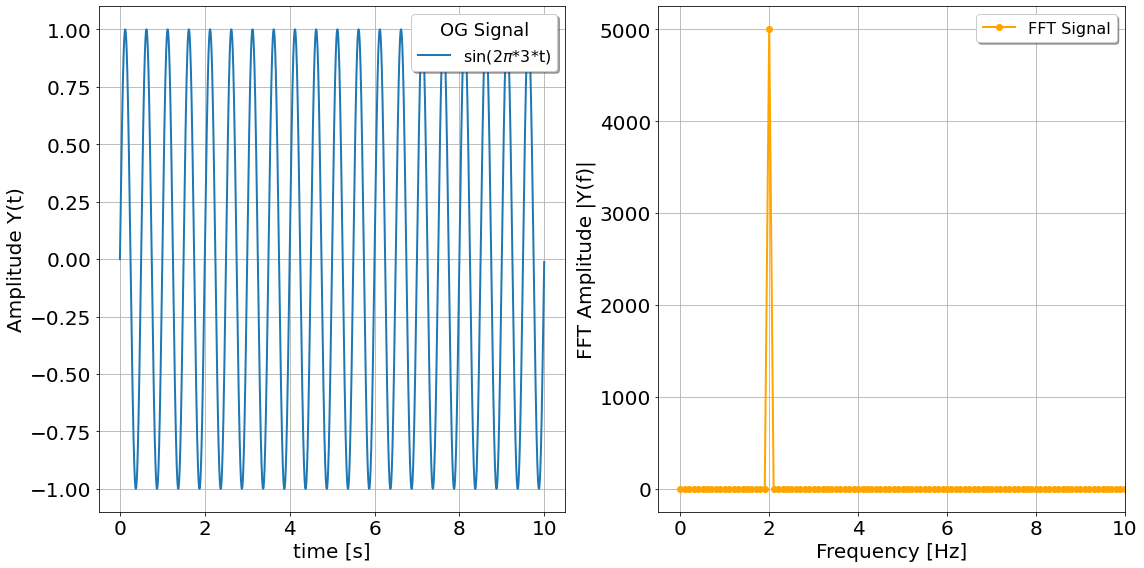

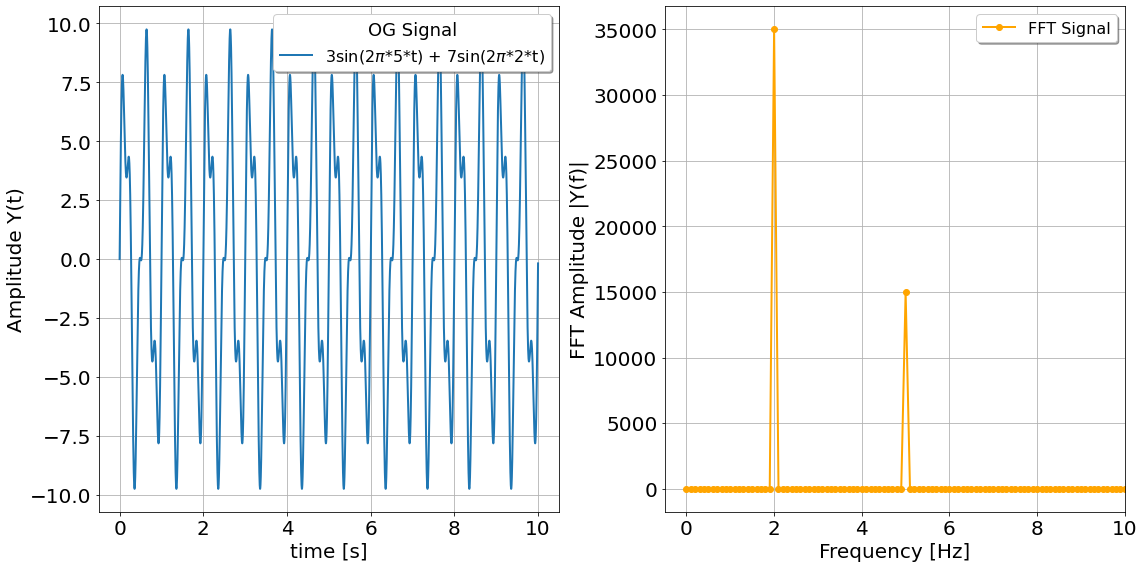

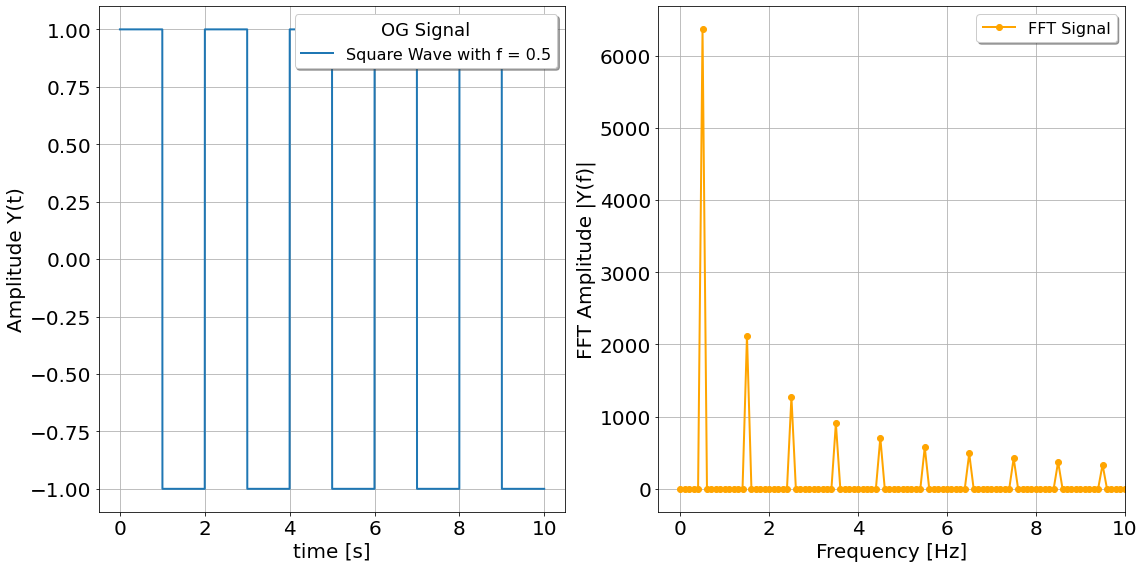

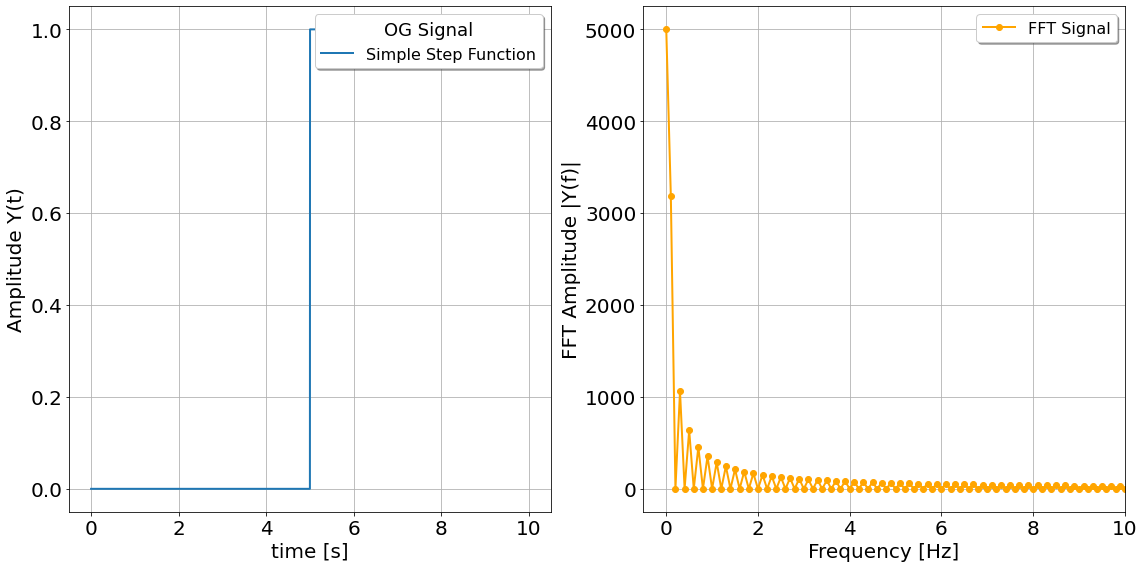

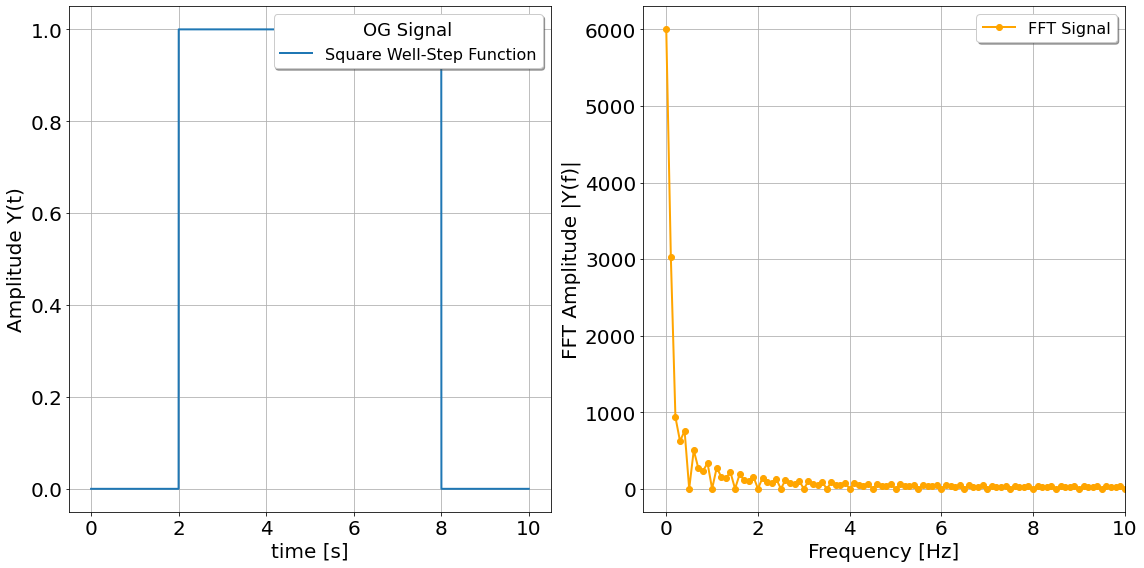

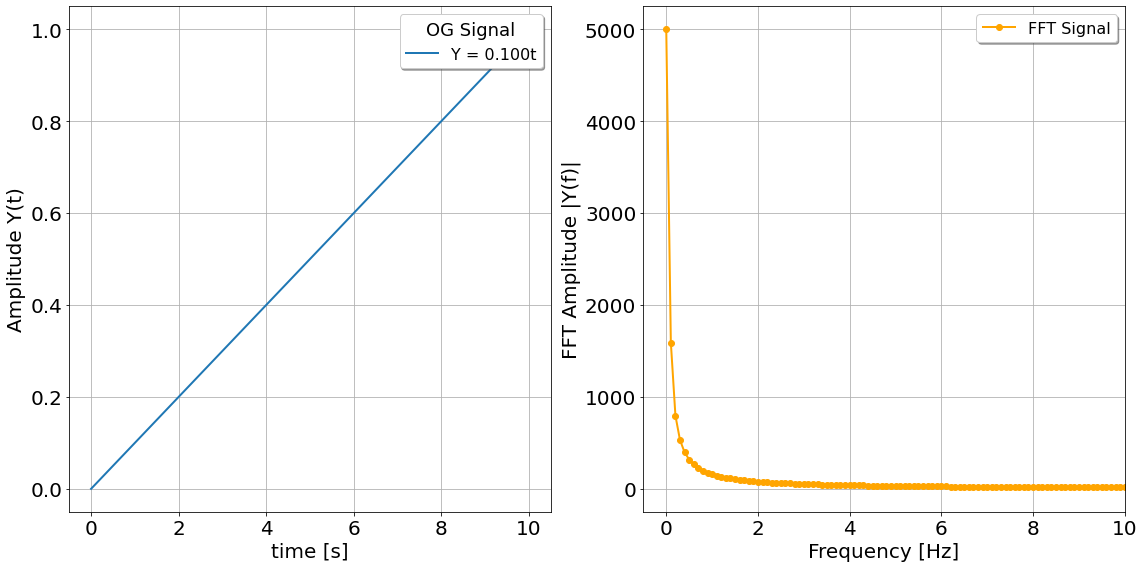

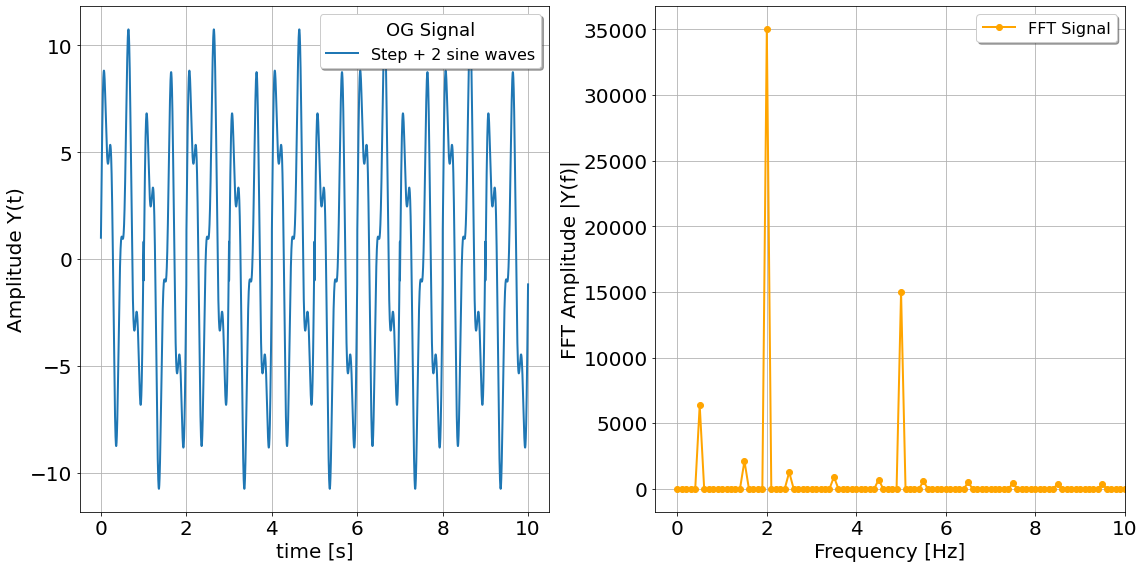

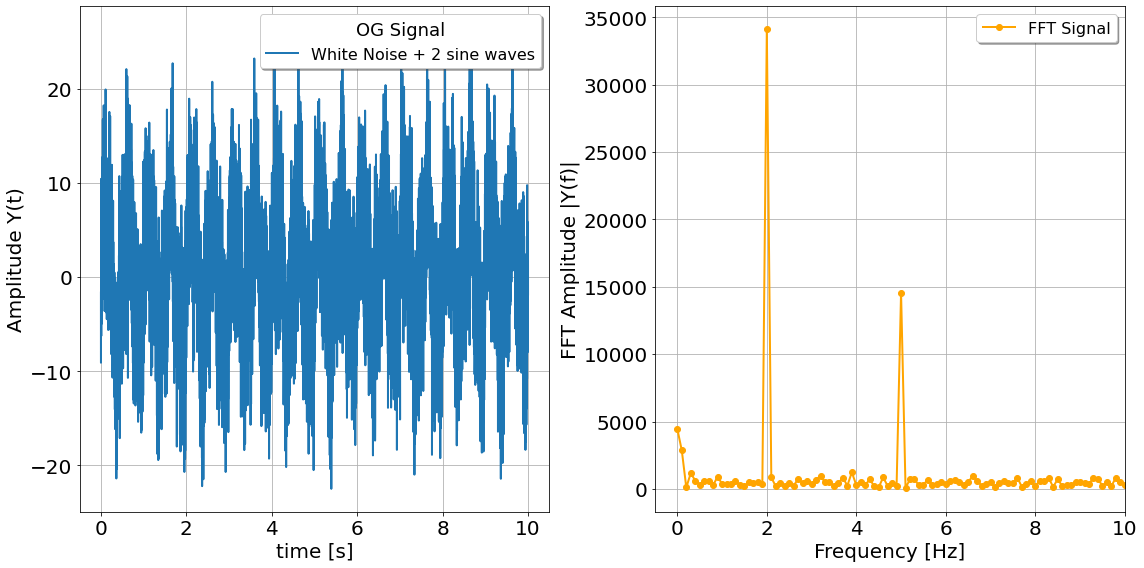

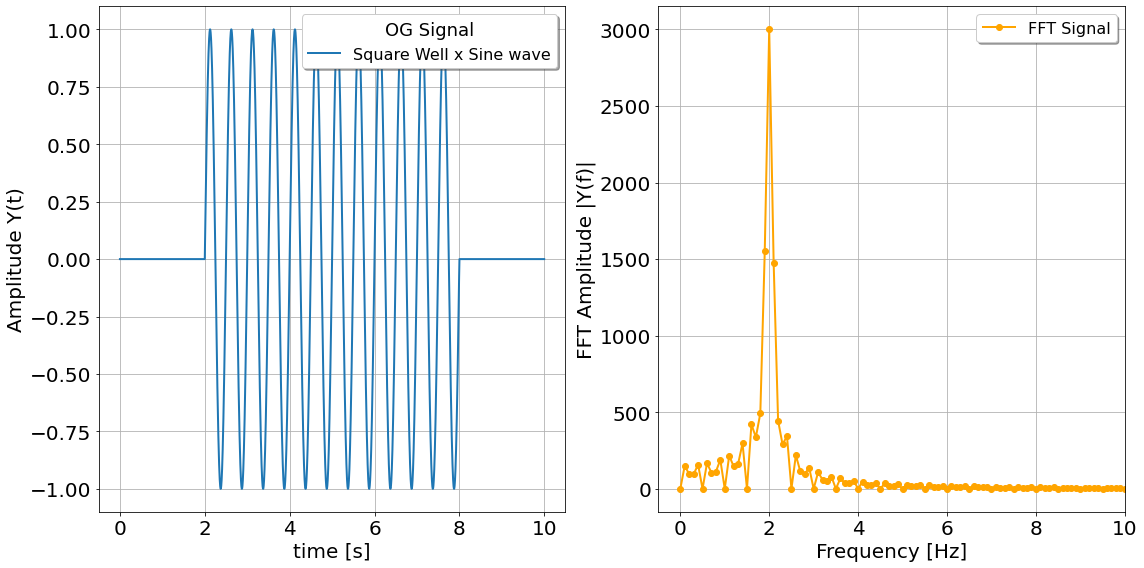

In [2]:
#--Defining dummy time series and anonymous function for y(t) = Asin(2pi*f*t)

#sr = 2000 #sample rate
#dt = 1/sr #

dt = 0.001 #defining time step / sampling interval
sr = 1/dt #defining sampling rate
print('With dt = %0.4f, our sampling rate is %0.2fHz'%(dt, sr))
afT = np.arange(0,10, dt)
mu, sigma = 0, 5
afWhite = np.random.normal(mu, sigma, len(afT)) #making white noise based on normal (Gaussian) distribution
print('Number of dtps in our time series is %0.2f'%(len(afT)/dt))

"""number of dtps = (Signal Range)/dt = (Signal Range)*sr
    where sr = dtps/(Signal Range)
    -Alternatively-
    (time step) dt = 1/sr

""";
dtps = 50 #number of datapoints
#afT = np.linspace(0, 10, dtps) #defining time array from 0-10sec
#afT = np.arange(0,10,dt)
#print(afT)
afAng = np.linspace(0, 2*np.pi, dtps) #defining angle array from 0-2pi
    #----Defining anonymous functions (Python's version of explicit math functions)
fSine = lambda A,f,t: A*np.sin(2*np.pi*f*t)
fSine_phase = lambda A, f, t, phi: A*np.sin(2*np.pi*f*t-phi)
#print(afT,'\nn', afAng)
#plt.plot(afT, afY(1,afT), label = r'sin($\omega$t)-single period')

def show_sig_fft(afTime, afSignal, achSig):
    """Creates two plots: OG signal function(Left) and FFT signal(Right)"""
       ##Create subplot parameters
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16, 8)) #setting size of subplots
    """For 1x2 Subplots: figsize = (15,10), title size =24, axis label/tick size = 20, legend font = 18
    For 2x2 Subplots: figsize = (20,18), title size =28, axis label/tick size = 24, legend font = 24
    For 2x4 subplots: figsize = (30,18), title size = 28, axis label/ticksize = 24, legend font = 20
    For 2x3 subplots: figsize = (25,18), title size = 28, axislabel/ticksize = 24, legend font = 20
    For 2x1 Subplots: figsize = (10,20), title size =22, axis label/tick size = 22, legend font = 22"""
    fsize = 20 #fontsize of axis labels/ticks
    legsize = 18 #legend fontsize
    tsize = 15 #titlesize
    #Plotting OG Signal
    ax1.plot(afTime, afSignal, lw = 2, label = '%s'%(achSig))
    ax1.set_xlabel('time [s]', fontsize = fsize)
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax1.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax1.legend(title = 'OG Signal', title_fontsize = legsize, loc = 'upper right', prop={'size': legsize-2},shadow=True)
    ax1.grid()
    #Plotting Signal in Frequency Domain
    Sig_fft = fft(afSignal) ##applying FFT to signal
    #---Defining FT frequency axis
    N_samples = len(Sig_fft) #number of datapoints/samples in signal
    T = N_samples*dt #period/window length of signal
    k = np.arange(N_samples)
    afFreq = k/T #defining frequency axis of FT
    nyqF = 1/(2*dt) #defining nyquist frequncy
    print('Nyquist Freq = %0.2fHz'%nyqF)
    #afFreq = np.linspace(0, nyqF, N_samples) #alternate definition of frequency axis
    #print(afFreq[0], afFreq[-1])
    #print(afFreq[1]-afFreq[0], 1/T)
    #afNorm = dt/len(afTime)
    ax2.plot(afFreq, np.abs(Sig_fft), lw = 2, color = 'orange', marker = 'o', label = 'FFT Signal')
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax2.set_ylabel('FFT Amplitude |Y(f)|', fontsize = fsize)
    #ax2.set_xlim(-2,10)
    ax2.set_xlim(-0.5, 10)
    ax2.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax2.legend(loc = 'upper right', prop={'size': legsize-2}, shadow=True)
    ax2.grid()
    plt.tight_layout() #ensures subplots don't overlap
    return;

#--Plotting FFT signal for y(t) = sin(2pi*3t): Pure Sine wave single freq
afY1 = fSine(1, 2, afT)
achFunc1 = r'sin(2$\pi$*3*t)'
show_sig_fft(afT, afY1, achFunc1)

#--Plotting FFT signal for y(t) = 3sin(2pi*5*t)+ 7sin(2pi*2*t): Two Sine waves with different frequencies and amplitudes added together
afY2 = fSine(3, 5, afT) + fSine(7, 2, afT)
achFunc2 = r'3sin($2\pi$*5*t) + 7sin($2\pi$*2*t)'
show_sig_fft(afT, afY2, achFunc2)

#--Plotting FFT for Square Wave of a given frequency
afY3 = signal.square(2*np.pi*0.5*afT)
achFunc3 = "Square Wave with f = 0.5"
show_sig_fft(afT, afY3, achFunc3)

#--Plotting FFT for step function.
    #Case 1: Y(t >=5) = 1 and Y(t<5) = 0
afY4 = np.zeros(len(afT))
afY4[afT >= 5] = 1
show_sig_fft(afT, afY4, "Simple Step Function")
    #Case 2, Square Well: Y(t-else) = 0 and Y(7>= t >=5) = 1
afY5 = np.zeros(len(afT))
for i in range(len(afT)):
    if (afT[i]>= 2 and afT[i] <= 8):
        afY5[i] = 1
show_sig_fft(afT, afY5, "Square Well-Step Function")

#--Plotting FFT for Slowly increasing straight line
m_slope = 0.1
afY6 = m_slope*afT
achF6 = 'Y = %0.3ft'%(m_slope)
show_sig_fft(afT, afY6, achF6)

#--Plotting FFT for 2 Sine waves plus step function:
show_sig_fft(afT, afY3 + afY2, 'Step + 2 sine waves')
#--Plotting FFT for 2 Sine waves plus square well(special function):
show_sig_fft(afT, afY4 + afY2+afWhite, 'White Noise + 2 sine waves')

#--Plotting FFT for Square Well*Sine wave (special step function)
show_sig_fft(afT, afY5*afY1, 'Square Well x Sine wave')

#--Plotting FFT for White Noise
#show_sig_fft(afT, afWhite, 'White Noise')


#afY3[]
#fig = plt.figure(10,10)
#plt.plot(afT, afY3)


	With 1sec signal, dt = 0.0010, sampling rate = 1000.00Hz, number of dtps = 2000000, f_ray = 0.50 Hz


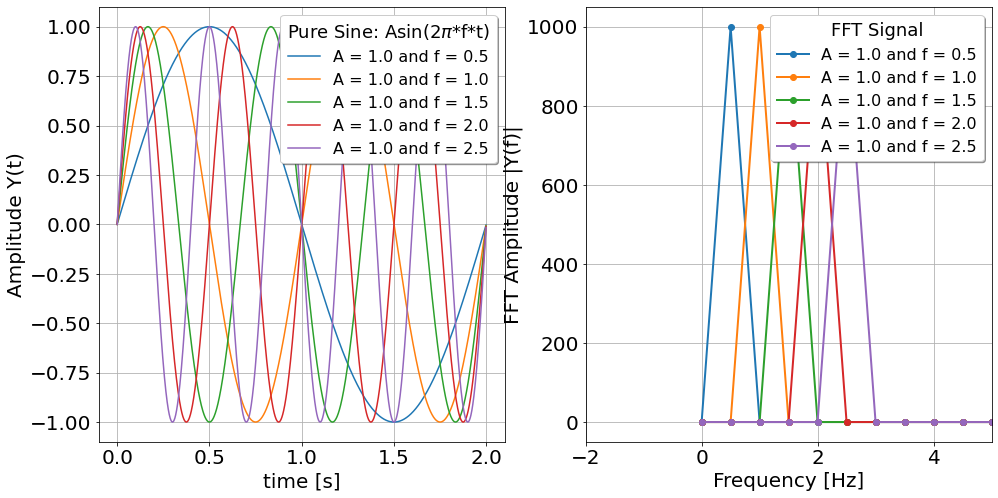

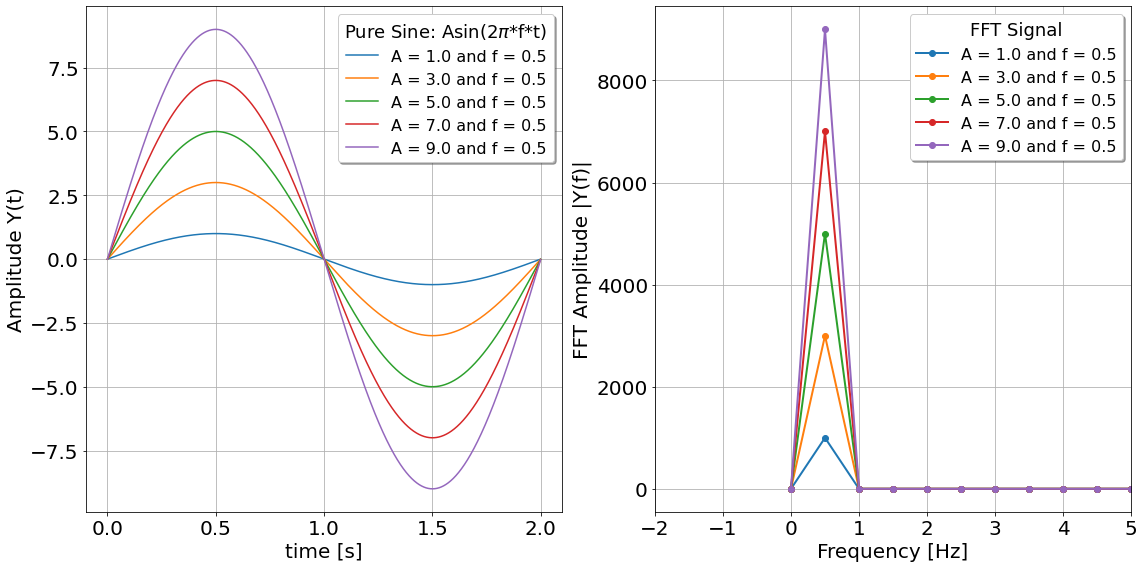

In [3]:
def Plot_sine_FFT(ax1,ax2, ampl, freq,time, sig_array):
#Creates plot of oscillation curve with above inputs inputs
    #fig = plt.figure(nfig, figsize = (16,8))
    #fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16, 8)) #setting size of subplots
    #fig = plt.figure(nfig, figsize = (16,8))
    #ax1 = fig.add_subplot(121)
    #ax2 = fig.add_subplot(122)
    fsize = 20 #fontsize of axis labels/ticks
    legsize = 18 #legend fontsize
    tsize = 15 #titlesize
    achLabel = "A = %0.1f and f = %0.1f"%(ampl, freq) #defining plot labels
    '''
    if achInput = 'Freq': #looping through input frequency array
        achLabel = 'A = %0.2f and f = $0.2f'%()
        achLegTit = 'y(t) = Asin(2)'
    elif achInput = 'Amp': #looping though input amplitude array
    else:
        achLabel = achLegTit = 'Error Input'
    ''';
    #--Plot OG Signal
    ax1.plot(time, sig_array, label = '%s'%(achLabel))
    ax1.set_xlabel('time [s]', fontsize = fsize)
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax1.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax1.legend(title = 'Pure Sine: Asin(2$\pi$*f*t)', title_fontsize = legsize, loc = 'upper right', prop={'size': legsize-2},shadow=True)
    #---FT'ing Signal
    #'''
    Sig_fft = fft(sig_array) #applying FFT to signal
    N_samples = len(Sig_fft) #number of datapoints/samples in signal
    T = N_samples*dt #period/window length of signal
    k = np.arange(N_samples)
    afFaxis = k/T #defining frequency axis of FT
    #nyqF = 1/(2*dt) #defining nyquist frequncy
    #print('Nyquist Freq = %0.2fHz'%nyqF)
    ax2.plot(afFaxis, np.abs(Sig_fft), marker = 'o', lw = 2, label = '%s'%(achLabel))
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax2.set_ylabel('FFT Amplitude |Y(f)|', fontsize = fsize)
    ax2.set_xlim(-2,5)
    ax2.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax2.legend(title = 'FFT Signal', title_fontsize = legsize,loc = 'upper right', prop={'size': legsize-2}, shadow=True)
    plt.tight_layout()
    #''';


def FFT_single_sine():
    """Fourier Transform pure sine wave with different frequencies(1) and amplitudes(2)"""
    anF_test0 = np.arange(1,6) #define dummy frequency array from 1-5
    anAmp = np.array([1,3,5,7,9])
    #print('Input Freq:', anF_test, '\nInput Amplt:', anAmp)
    dt = 0.001 #defining time step / sampling interval
    sr = 1/dt #defining sampling rate
    afT_test = np.arange(0,2, dt)
    print('\tWith %dsec signal, dt = %0.4f, sampling rate = %0.2fHz, number of dtps = %d, f_ray = %0.2f Hz'
          %(afT_test[-1], dt, sr, len(afT_test)/dt, 1/(len(afT_test)*dt)) )
    anF_test = anF_test0 * (1/(len(afT_test)*dt))
    
    #Plot inputs: fig size, Amplitude, Frequency, time array, SineWave Function and data arrays 
    #Plot_sine_FFT(1, 'Freq',anAmp[0], anF_test[0],afT_test, fSine(anAmp[0], anF_test[0], afT_test))

    
    #Plotting FT signal for several frequencies(Case1, Amp = 1) and amplitudes(Case2, f = 1)
    fig1 = plt.figure(1, figsize = (16,8)) #Case1 Subplot Setup
    ax1_1 = fig1.add_subplot(121)
    ax2_1 = fig1.add_subplot(122)
    #--
    fig2 = plt.figure(2, figsize = (16,8)) #Case2 Subplot Setup
    ax1_2 = fig2.add_subplot(121)
    ax2_2 = fig2.add_subplot(122)
    """KEY NOTE: when looping data on the same subplots, I need to have already the subplot presets and loop 
    through the explicit 'ax' plot variables"""
    for i in range(len(anAmp)):
        #Plot inputs: AX1,AX2, Amplitude, Frequency, time array, SineWave Function
        #--Case1: A = 1, multiple frequencies
        Plot_sine_FFT(ax1_1,ax2_1, anAmp[0], anF_test[i],afT_test, fSine(anAmp[0], anF_test[i], afT_test))
         #--Case2: multiple amplitudes, f = 1
        Plot_sine_FFT(ax1_2,ax2_2, anAmp[i], anF_test[0],afT_test, fSine(anAmp[i], anF_test[0], afT_test))
    ax1_1.grid(),     ax1_2.grid(),    ax2_1.grid(), ax2_2.grid()

    return;



FFT_single_sine()

Length of OG Data = 200 
Length of DownSampled Data = 100
Rayliegh F = 0.20Hz 	Nyquist F = 20.00Hz


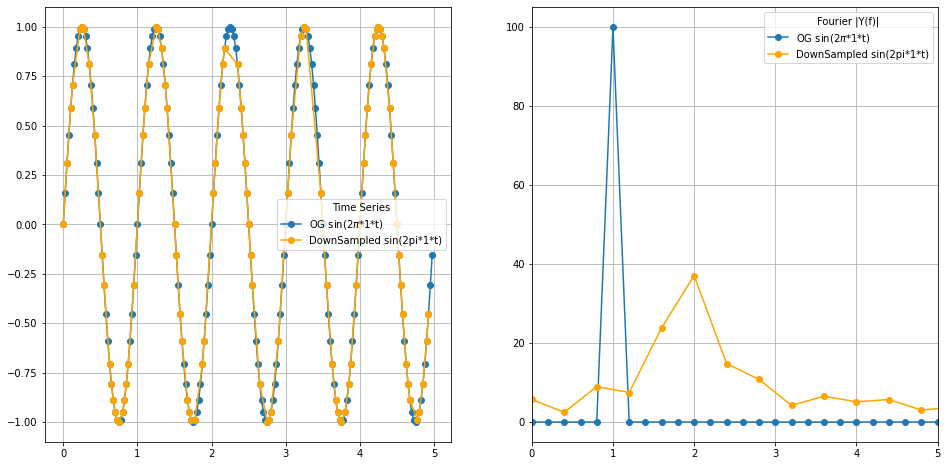

In [4]:
####Playing with Aliasing and Downsampling Data------------
def do_FFT(xdata, deltaT):
    """Do FFT and return Fourier coefficients and frequency axis array"""
    fft_x = fft(xdata) ##applying FFT to data
    #---Defining FT frequency axis
    N_samples = len(fft_x) #number of datapoints/samples in signal
    T = N_samples*deltaT #period/window length of signal
    k = np.arange(N_samples)
    afFreq = k/T #defining frequency axis of FT
    return (fft_x, afFreq);

def alias_data():
    """Alias and DownSample data"""
    #--OG Data
    dt = 0.025
    afT = np.arange(0,5,0.025)
    N = len(afT)
    f_ray = 1/(N*dt)
    f_nyq = 1/(2*dt)
    OG_data = fSine(1,1,afT)
    #--Downsampled Data
    ind_rand = np.random.randint(0, N, size = 150)
    afT_rand = np.delete(afT, ind_rand) #choose time array that omits random integers
    print('Length of OG Data = %d \nLength of DownSampled Data = %d'%(N, len(afT_rand)))
    print('Rayliegh F = %0.2fHz \tNyquist F = %0.2fHz'%(f_ray, f_nyq) )
    DS_data = fSine(1,1,afT_rand)
    #Plotting OG and Downsampled Data
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16, 8)) #setting size of subplots
    #fig1 = plt.figure(1, figsize = (8,8))
    ax1.plot(afT, OG_data, marker = 'o', label = r'OG sin(2$\pi$*1*t)')
    ax1.plot(afT_rand, DS_data, marker='o', color = 'orange', label = 'DownSampled sin(2pi*1*t)')
    ax1.legend(title  = 'Time Series')
    ax1.grid()
    #Plotting FFT of OG and DS Data
    [OG_fft, OG_freq] = do_FFT(OG_data, dt)
    [DS_fft, DS_freq] = do_FFT(DS_data, dt)
    ax2.plot(OG_freq, np.abs(OG_fft), marker = 'o', label = r'OG sin(2$\pi$*1*t)')
    ax2.plot(DS_freq, np.abs(DS_fft), marker='o', color = 'orange', label = 'DownSampled sin(2pi*1*t)')
    ax2.legend(title  = 'Fourier |Y(f)|')
    ax2.set_xlim(0, f_nyq/4)
    ax2.grid()
    return;

alias_data()


In [5]:
#--------Showing OG Signal and FFT PSD------v

def show_sig_fftPSD(afTime, afSignal, achSig, fDT, dNpts):
    """Creates two plots: OG signal function(Left) and corresponding FFT PSD (Right)"""
       ##Create subplot parameters
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16, 8)) #setting size of subplots
    fsize = 20 #fontsize of axis labels/ticks
    legsize = 18 #legend fontsize
    tsize = 15 #titlesize
    #Plotting OG Signal
    ax1.plot(afTime, afSignal, lw = 2, label = '%s'%(achSig))
    ax1.set_xlabel('time [s]', fontsize = fsize)
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    #minor_ticks1 = np.arange(0, afTime[-1], fDT) #defining FFT tick axis
    #ax1.set_xticks(afTime, minor=True)
    #ax1.set_xlim(0, 0.4)
    ax1.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax1.legend(title = 'OG Signal', title_fontsize = legsize, loc = 'upper right', prop={'size': legsize-2},shadow=True)
    ax1.grid(which = 'both')
    #Plotting Signal in Frequency Domain
        #-Generate FFT PSD
    afNorm = fDT/dNpts #norm factor relating |Y[k]|^2 to S[k] for default data window
    [sig_fft, afFreq] = do_FFT(afSignal, fDT) #apply FFT to signal and return Y[k]
    fftPSD = afNorm*np.abs(sig_fft)**2
    nyqF = 1/(2*fDT) #defining nyquist frequncy
    f_ray = 1/(dNpts*fDT) #defining rayleigh frequency
    print('Nyquist Freq = %0.2fHz, Rayleigh Freq = %0.3fHz'%(nyqF, f_ray))
    ax2.plot(afFreq, fftPSD, lw = 2, color = 'orange', marker = 'o', label = 'FFT Signal')
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax2.set_ylabel('FFT PSD S(f)', fontsize = fsize)
    #minor_ticks = #np.arange(0, afFreq[-1], f_ray) #defining FFT tick axis
    ax2.set_xticks(afFreq, minor=True)
    ax2.set_xlim(-0.5, 8)
    ax2.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax2.legend(loc = 'upper right', prop={'size': legsize-2}, shadow=True)
    ax2.grid(which = 'both')
    #-Color Section of Time Series and FFT background (highlight dt and df)
    #ax2.axvspan(4.0, 4.25 , facecolor='tab:green', alpha=0.3) # alpha is color transparency
    #ax1.axvspan(0.1, 0.1+fDT , facecolor='tab:blue', alpha=0.3) # alpha is color transparency
    plt.tight_layout() #ensures subplots don't overlap
    #plt.savefig('puresine3f0_&fftPSD.png', bbox_inches='tight', facecolor = 'w')
    return;

#-----------------Main-----------------v
def create_plot_sig_fftPSD():
    """Plot OG signal and corresponding FFT PSD"""
    #-Define time series---
    dt = 0.01 #defining time step / sampling interval
    sr = 1/dt #defining sampling rate
    print('With dt = %0.4f, our sampling rate is %0.2fHz'%(dt, sr))
    afT = np.arange(0,4, dt)
    np.random.seed(3) #define seed so we get consistent random values
    mu, sigma = 0, 5
    afWhite = np.random.normal(mu, sigma, len(afT)) #making white noise based on normal (Gaussian) distribution
    print('Number of dtps in our time series is %0.2f'%(len(afT)/dt))
    #--Plotting FFT PSD signal for y(t) = sin(2pi*3t): Pure Sine wave single freq
    afY1 = fSine(1, 3, afT)
    achFunc1 = r'sin(2$\pi$*3*t)'#\nt = [0,4]sec
    show_sig_fftPSD(afT, afY1, '%s\nt = [0,4]sec'%achFunc1, dt, len(afT))
    return;
#create_plot_sig_fftPSD()


### (6-11-2024) Creating Plots for jgrTechnical Paper of Signal Detection with Adaptive MTM PSD
* Great explanation by MX Cohen on what aliasing is in relation to the Nyquist Frequency:
https://canlab.github.io/_pages/tutorials/html/sin_cos_fft.html
* Nice explanation for causes of power spectral leakage which is indeed due to DFT of finite data series being an inherent FT of a data-taper. Where our finite signal = "infinite signal" data-tapered by a window function. Resulting FT is convolution of the signal FT with the FT of a rectangular window. Where we know for a rectangular window produces the ringing effect and thus the observed spectral flaring/side lobes
"FT of a product is the convolution of the two FTs"
https://dsp.stackexchange.com/questions/10120/why-does-spectral-leakage-arise-in-an-fft
    * additional discussion on "windowing data" being the cause of spectral leakage:
https://dsp.stackexchange.com/questions/34211/is-spectral-leakage-due-to-windowing-different-for-the-dtft-and-dft. incidentally, having a windowed sinusoid with a non-integer(ie. 3/2) number of periods or just being out of phase will also introduce spectral power leakage
* Adding white noise via np.random.normal: https://stackoverflow.com/questions/14058340/adding-noise-to-a-signal-in-python
* Having grid lines overlap with tick marks: https://stackoverflow.com/questions/24943991/change-grid-interval-and-specify-tick-labels
    * specifically highlight xaxis fourier frequencies
* Making plots occupy more than one subplot axis: https://stackoverflow.com/questions/2265319/how-to-make-an-axes-occupy-multiple-subplots-with-pyplot

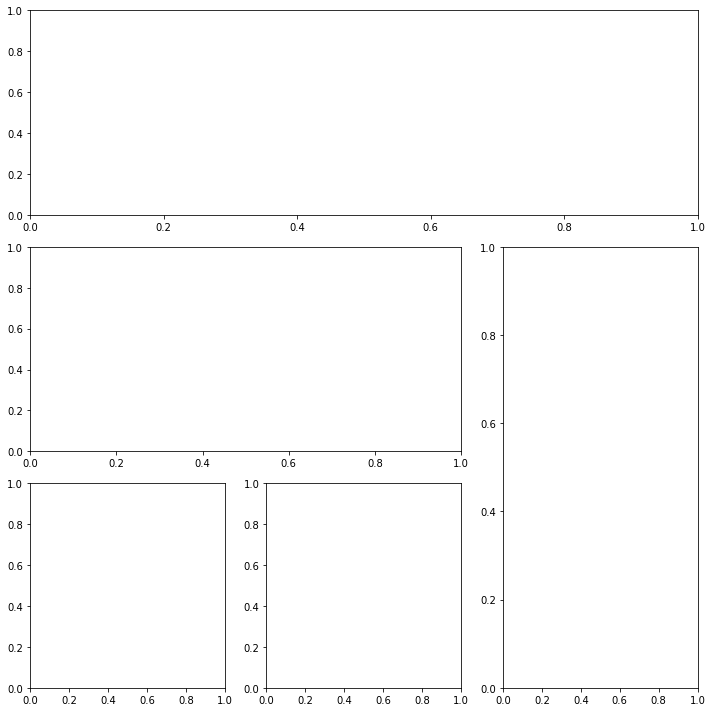

In [6]:

###Different ways of having a plot occupy multiple subplot axes
def play_gridspec():
    fig = plt.figure(figsize = (10,10))
    gs = GridSpec(3, 3, figure=fig)
    
    ax1 = fig.add_subplot(gs[0, :])
    # identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))
    ax2 = fig.add_subplot(gs[1, :2]) #equivalent to gs[1,:-1]
    ax3 = fig.add_subplot(gs[1:, 2]) #equivalen to gs[1:,2]
    ax4 = fig.add_subplot(gs[2, 0]) #equivalent to gs[-1,0]
    ax5 = fig.add_subplot(gs[2, 1]) #equivalent to gs[-1,-2]
    plt.tight_layout()
    return;
play_gridspec()

def play_subplotmosaic():
    fig, axd = plt.subplot_mosaic([['left', 'right'],['bottom', 'bottom']],
                              constrained_layout=True)
    #axd['left'].plot(x, y, 'C0')
    #axd['right'].plot(x,)
    #axd['bottom'].plot()
    return;
#play_subplotmosaic()

Rayleigh frequency is 0.2
Creating Prieto MTSPEC class for Data(NW = 2, Ktpr = 3)


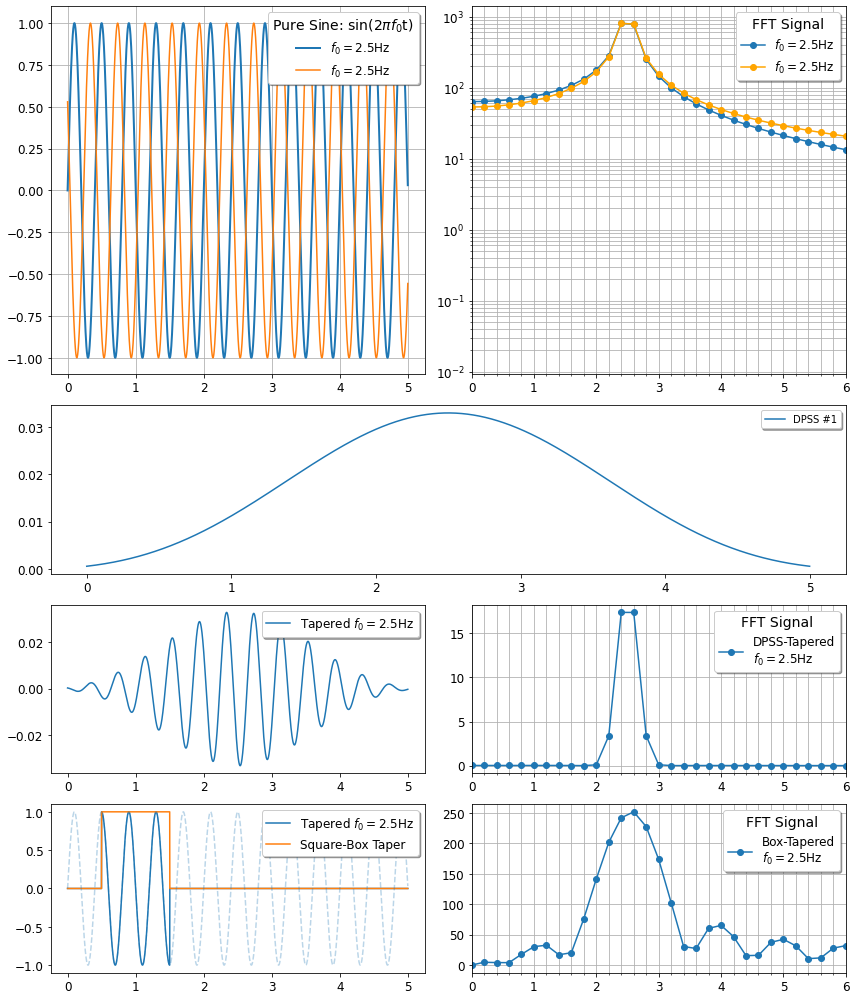

In [7]:
"""Plot of FFT of pure sine wave, pure sine wave phase shifted(non-zero at time series border),
and phase-shifted pure sine wave data-tapered by 1st slepian sequence
""";

def get_pietro_dpss(inData, tdata, NW, Ktpr=None):
    """Extract Slepian seqs and aMTM PSD params from Pietro's MTM Python Package"""
    if Ktpr is None:
        Ktpr = 2*NW-1 #default value
    else:
        Ktpr = Ktpr 
    dt = tdata[1] - tdata[0] #time step / sampling interval
    afData_nmean = inData-np.nanmean(inData) #removing mean from data array
    #--Extract Pietro MTM Spectra Data
    print('Creating Prieto MTSPEC class for Data(NW = %d, Ktpr = %d)'%(NW, Ktpr))
    psd_class = MTSpec(afData_nmean, NW, Ktpr, dt, nfft = len(tdata), iadapt=0) 
    afFreq ,afRaw_Sk = psd_class.rspec() #return PDS at positive frequencies (up to Nyquist Freq)
    Vn = psd_class.vn #Slepiean sequences/ DPSS tapers. Indexes as Vn[:, nth taper]
    '''
    print('Lenght of 1st slep seq = %d and Length of inputted data series = %d'%(len(Vn[:,0]), len(tdata)))
    #plt.plot(inData, label = 'OG Data')
    for i in range(Ktpr):
        plt.plot(Vn[:,i], label = 'DPSS #%d'%(i+1))
    plt.legend(loc = 'upper right')
    ''';
    return(afFreq, afRaw_Sk, Vn);

def plot_fft_puresine_phaseshift():
    #-OG Data params-
    ds = 500 #sampling rate, equivalent to dt = 0.002s
    dt = 1/ds
    afT = np.arange(0, 5, dt) #5 second interval with 1000 dtps (N = T*ds or T = N*dt)
    N = len(afT)
    f_ray = 1/(N*dt)
    f_nyq = 1/(2*dt)
    print('Rayleigh frequency is', f_ray)
    #-Defining various time series
    freq1 = 2.5
    freq2 = 2.5#2.5#2.9
    phase = 3.7
    OG_sine = fSine(1,freq1,afT) #pure sine wave with f = 5Hz (cycles/sec)
    PH_sine = fSine_phase(1, freq2, afT, phase) #pure sine wave phase-shifted by 3pi/4
    [afFreq_mtm, afSk_mtm, aafVn] = get_pietro_dpss(OG_sine, afT, 2) #extract Pietro aMTM PSD and dpss
        #-defining square box
    afSquare = np.zeros(len(afT))
    for i in range(len(afT)):
        if (afT[i]>= 0.5 and afT[i] <= 1.5): #0.5 to 1.5 for 0-2 seconds window
            afSquare[i] = 1
     #-FFTs of various time series
    [OG_fft, OG_freq] = do_FFT(OG_sine, dt) #FFT of pure sine with integer f0
    [PH_fft, PH_freq] = do_FFT(PH_sine, dt) #FFT of pure sine with non-integer f0
    [slptpr_PH_fft, slptpr_PH_freq] = do_FFT(aafVn[:,0]*PH_sine, dt) #FFT of non-integer f0 tapered by 1st DPSS
    [boxtpr_OG_fft, boxtpr_OG_freq] = do_FFT(afSquare*OG_sine, dt) #FFT of pure sine(integer f0) tapered by square box (equal edges)

    #-Using GridSpec to plot the various time series and corresponding FFTs
    achPS = r'sin(2$\pi f_0$t)'
    #achDiv = r'$(\nabla\cdot B)/\mu_0$'
    #jdr_xy = r'$(\hat{J}\cdot\hat{r})_{xy}$'
    #print(achPS, achDiv
    #print('For int f0, x[0] = %0.3f and x[-1] = %0.3f'%(OG_sine[0], OG_sine[-1]))
    #print('For nonint f0, x[0] = %0.3f and x[-1] = %0.3f'%(PH_sine[0], PH_sine[-1]))
    fig = plt.figure(figsize = (12,14))
    gs = GridSpec(5, 2, figure=fig)
    ax1 = fig.add_subplot(gs[:2, 0]) #pure sine(int f0 and nonint f0)
    #ax2 = fig.add_subplot(gs[1, 0]) #pure sine (nonint f0)
    ax2 = fig.add_subplot(gs[:2, 1]) #FFT of both pure sine waves
    ax3 = fig.add_subplot(gs[2, :]) #DPSS taper
    ax4 = fig.add_subplot(gs[3, 0]) #DPSS tapered pure sine(nonint f0)
    ax5 = fig.add_subplot(gs[3, 1]) #FFT of DPSS tapered pure sine(non int f0)
    ax6 = fig.add_subplot(gs[4, 0]) #square box tapered pure sine(int f0)
    ax7 = fig.add_subplot(gs[4, 1]) #FFT of square box tapered pure sine(int f0)
    fsize = 12 #fontsize of axis labels/ticks
    legsize = 14 #legend fontsize
    tsize = 12 #titlesize
        #plotting things----v
    ax1.plot(afT, OG_sine, lw = 2, label = r'$f_0 = %0.1f$Hz'%(freq1))
    ax1.plot(afT, PH_sine, label = r'$f_0 = %0.1f$Hz'%(freq2))
    ax1.grid(which = 'both')
    ax1.legend(title = r'Pure Sine: %s'%achPS, loc = 'upper right', shadow = True, title_fontsize = legsize, prop={'size': legsize-2})
    
    ax2.semilogy(OG_freq, np.abs(OG_fft), marker = 'o', label = r'$f_0 = %0.1f$Hz'%(freq1))
    ax2.semilogy(PH_freq, np.abs(PH_fft), marker='o', color = 'orange', label = r'$f_0 = %0.1f$Hz'%(freq2))
    minor_ticks = np.arange(0, PH_freq[-1], f_ray)
    ax2.set_xticks(minor_ticks, minor=True)
    ax2.set_xlim(0, 6)
    ax2.grid(which = 'both')
    ax2.legend(title = 'FFT Signal', loc = 'upper right', shadow = True, title_fontsize = legsize, prop={'size': legsize-2})
    
    ax3.plot(afT, aafVn[:,0], label = 'DPSS #1')
    ax3.legend(loc = 'upper right', shadow = True)
    ax4.plot(afT, aafVn[:,0]*PH_sine, label = r'Tapered $f_0 = %0.1f$Hz'%(freq2))
    ax4.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax5.plot(slptpr_PH_freq, np.abs(slptpr_PH_fft), marker = 'o', label = 'DPSS-Tapered\n'+r'$f_0 = %0.1f$Hz'%(freq2))
    ax5.set_xticks(minor_ticks, minor=True)
    ax5.set_xlim(0, 6)
    #ax5.set_xticks(minor_ticks, minor=True)
    ax5.grid(which = 'both')
    ax5.legend(title = 'FFT Signal', loc = 'upper right', shadow = True, title_fontsize = legsize, prop={'size': legsize-2})
    
    ax6.plot(afT, afSquare*OG_sine, label = r'Tapered $f_0 = %0.1f$Hz'%(freq1))
    ax6.plot(afT, afSquare, label = 'Square-Box Taper')
    ax6.plot(afT, OG_sine, ls = '--', color = 'tab:blue', alpha = 0.3)
    ax6.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax7.plot(boxtpr_OG_freq, np.abs(boxtpr_OG_fft), marker = 'o',label = 'Box-Tapered\n'+r'$f_0 = %0.1f$Hz'%(freq1))
    ax7.set_xticks(minor_ticks, minor=True)
    ax7.set_xlim(0, 6)
    ax7.grid(which = 'both')
    ax7.legend(title = 'FFT Signal', loc = 'upper right', shadow = True, title_fontsize = legsize, prop={'size': legsize-2})
        #-Setting tickparameter size
    ax1.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax2.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax3.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax4.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax5.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax6.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax7.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize

    #ax5 = fig.add_subplot(gs[2, 1]) #equivalent to gs[-1,-2]
    '''
    fig, ax1 = plt.subplots(7,1, figsize = (8, 12)) #setting size of subplots
    ax1[0].plot(afT, OG_sine, lw = 2, label = r'$f_0 = %0.1f$Hz'%(freq1))
    ax1[0].plot(afT, PH_sine, label = r'$f_0 = %0.1f$Hz'%(freq2))
    ax1[0].grid(which = 'both')
    ax1[0].legend(title = r'Pure Sine: %s'%achPS, loc = 'upper right')#, title_fontsize = legsize, loc = 'upper right', prop={'size': legsize-2},shadow=True)
    
    ax1[1].plot(OG_freq, np.abs(OG_fft), marker = 'o', label = r'$f_0 = %0.1f$Hz'%(freq1))
    ax1[1].plot(PH_freq, np.abs(PH_fft), marker='o', color = 'orange', label = r'$f_0 = %0.1f$Hz'%(freq2))
    minor_ticks = np.arange(0, PH_freq[-1], f_ray)
    ax1[1].set_xticks(minor_ticks, minor=True)
    ax1[1].set_xlim(0, 6)
    ax1[1].grid(which = 'both')
    ax1[1].legend(title = 'FFT Signal', loc = 'upper right')#, title_fontsize = legsize,loc = 'upper right', prop={'size': legsize-2}, shadow=True)
    
        #-1st DPSS plot
    ax1[2].plot(afT, aafVn[:,0], label = 'DPSS #1')
    ax1[2].legend(loc = 'upper right')
    ax1[3].plot(afT, aafVn[:,0]*PH_sine, label = r'Tapered $f_0 = %0.1f$Hz'%(freq2))
    ax1[3].legend(loc = 'upper right')
    ax1[4].plot(slptpr_PH_freq, np.abs(slptpr_PH_fft), marker = 'o', label = r'DPSS-Tapered $f_0 = %0.1f$Hz'%(freq2))
    ax1[4].set_xlim(0, 6)
    ax1[4].legend(title = 'FFT Signal', loc = 'upper right')
    
    ax1[5].plot(afT, afSquare*OG_sine, label = r'Tapered $f_0 = %0.1f$Hz'%(freq1))
    ax1[5].plot(afT, afSquare, label = 'Square-Box Taper')
    ax1[5].plot(afT, OG_sine, ls = '--', color = 'tab:blue', alpha = 0.3)
    ax1[5].legend(loc = 'upper right')
    ax1[6].plot(boxtpr_OG_freq, np.abs(boxtpr_OG_fft), marker = 'o',label = r'Box-Tapered $f_0 = %0.1f$Hz'%(freq1))
    ax1[6].set_xlim(0, 6)
    ax1[6].legend(title = 'FFT Signal', loc = 'upper right')
    ''';
    plt.tight_layout()
    return;
    
plot_fft_puresine_phaseshift()

In [8]:
print('I really\nreally\nwanna\nbe your baby!')

I really
really
wanna
be your baby!


* (6-20-2024) The following is a brief email discussion with Simone on what the common normalization factor is with PSDs at FTs Y(f)
    * In Scipy, FFT(xn) is defined as just Y(f). Alternatively, IDL defines FFT(xn) as (1/N)Y(f)
    * For non-normalized data-tapers, PSD $S(f) = (\Delta{t}/\Sigma{w_i^2})|Y(f)|^2$ or $N_{orm}|Y(f)|^2$
        * For the DPSS tapers, $\Sigma{w_i^2} = 1$
        * For innate sample window, $\Sigma{w_i^2} = N$. My square box doesn't use entire sample window, just a segment
    * With Scipy's FFT: $S(f) = N_{orm}|FFT(x_n)|^2$ or $\sqrt{S(f)} = (\sqrt{N_{orm}})|FFT(x_n)|$
        * Using the DPSS taper: $S(f) = (\Delta{t})|FFT(x_n)|^2$
        * Using the square-box taper: $S(f) = ((\Delta{t}/\Sigma{w_i^2}))|FFT(x_n)|^2$

Rayleigh frequency is 0.2 and N =  2500
Creating Prieto MTSPEC class for Data(NW = 2, Ktpr = 3)
Sum of squares for square box = 2101.00
Sum of squares for DPSS#1 = 1.00


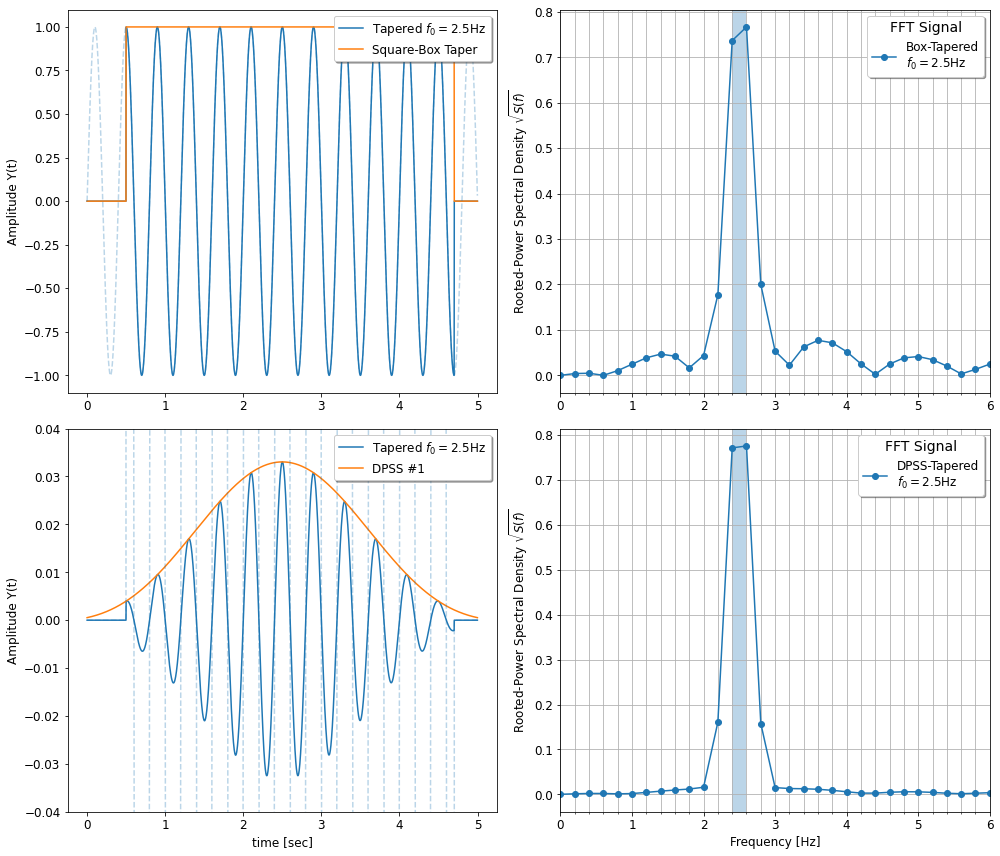

In [15]:
def plot_fft_sinentaper_example():
    #-OG Data params-
    ds = 500 #sampling rate, equivalent to dt = 0.002s
    dt = 1/ds
    afT = np.arange(0, 5, dt) #5 second interval with 1000 dtps (N = T*ds or T = N*dt)
    N = len(afT)
    f_ray = 1/(N*dt)
    f_nyq = 1/(2*dt)
    print('Rayleigh frequency is', f_ray, 'and N = ', N)
    afNorm = 1/(N*ds) # = dt/N, common normalization factor (for entire window) when computing PSD dirrectly from FFT
    #-Defining various time series
    freq1 = 2.5#2.5, 3.0
    OG_sine = fSine(1,freq1,afT) #pure sine wave with f = 5Hz (cycles/sec)
    #PH_sine = fSine_phase(1, freq2, afT, phase) #pure sine wave phase-shifted by 3pi/4
    #[afFreq_mtm, afSk_mtm, aafVn] = get_pietro_dpss(OG_sine, afT, 2) #extract Pietro aMTM PSD and dpss
        #-defining square box
    afSquare = np.zeros(len(afT))
    for i in range(len(afT)):
        if (afT[i]>= 0.5 and afT[i] <= 4.7): #;0.5 to 1.5 for 0-2 seconds window
            afSquare[i] = 1
    [afFreq_mtm, afSk_mtm, aafVn] = get_pietro_dpss(afSquare*OG_sine, afT, 2) #extract Pietro aMTM PSD and dpss
     #-FFTs of various time series
    [OG_fft, OG_freq] = do_FFT(OG_sine, dt) #FFT of pure sine with integer f0
    [boxtpr_OG_fft, boxtpr_OG_freq] = do_FFT(afSquare*OG_sine, dt) #FFT of pure sine(integer f0) tapered by square box (unequal edges)
    [slptpr_OG_fft, slptpr_OG_freq] = do_FFT(aafVn[:,0]*OG_sine*afSquare, dt) #FFT of pure sine(int f0) tapered by 1st DPSS
    print('Sum of squares for square box = %0.2f'%(np.sum(afSquare**2)))
    print('Sum of squares for DPSS#1 = %0.2f'%(np.sum(aafVn[:,0]**2)))
    afNorm_sq = dt/np.sum(afSquare**2)

    #[OG_fft, OG_freq] = do_FFT(OG_sine, dt) #FFT of pure sine with integer f0
    #[PH_fft, PH_freq] = do_FFT(PH_sine, dt) #FFT of pure sine with non-integer f0
    #[slptpr_PH_fft, slptpr_PH_freq] = do_FFT(aafVn[:,0]*PH_sine, dt) #FFT of non-integer f0 tapered by 1st DPSS
    #[boxtpr_OG_fft, boxtpr_OG_freq] = do_FFT(afSquare*OG_sine, dt) #FFT of pure sine(integer f0) tapered by square box (equal edges)

    #-Using GridSpec to plot the various time series and corresponding FFTs
    achPS = r'sin(2$\pi f_0$t)'
    fig = plt.figure(figsize = (14,12))
    gs = GridSpec(2, 2, figure=fig)
    ax1 = fig.add_subplot(gs[0, 0]) #square box tapered pure sine(int f0) w/ edge effects
    ax2 = fig.add_subplot(gs[0, 1]) #FFT of square box tapered pure sine(int f0)
    ax3 = fig.add_subplot(gs[1, 0]) #DPSS tapered pure sine(int f0) w/edge effects
    ax4 = fig.add_subplot(gs[1, 1]) #FFT of DPSS tapered pure sine(int f0)
  
    fsize = 12 #fontsize of axis labels/ticks
    legsize = 14 #legend fontsize
    tsize = 12 #titlesize
        #-Plotting Box-Taper
    ax1.plot(afT, afSquare*OG_sine, label = r'Tapered $f_0 = %0.1f$Hz'%(freq1))
    ax1.plot(afT, afSquare, label = 'Square-Box Taper')
    ax1.plot(afT, OG_sine, ls = '--', color = 'tab:blue', alpha = 0.3)
    ax1.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax2.plot(boxtpr_OG_freq, np.sqrt(afNorm_sq)*np.abs(boxtpr_OG_fft), marker = 'o',label = 'Box-Tapered\n'+r'$f_0 = %0.1f$Hz'%(freq1))
    minor_ticks = np.arange(0, OG_freq[-1], f_ray) #defining FFT tick axis
    ax2.set_xticks(minor_ticks, minor=True)
    ax2.set_xlim(0, 6)
    ax2.grid(which = 'both')
    ax2.legend(title = 'FFT Signal', loc = 'upper right', shadow = True, title_fontsize = legsize, prop={'size': legsize-2})
    ax2.set_ylabel('Rooted-Power Spectral Density $\sqrt{S(f)}$', fontsize = fsize)
         #-Plotting DPSS-Taper
    ax3.plot(afT, aafVn[:,0]*OG_sine*afSquare, label = r'Tapered $f_0 = %0.1f$Hz'%(freq1))
    ax3.plot(afT, aafVn[:,0], label = 'DPSS #1')
    ax3.plot(afT, OG_sine*afSquare, ls = '--', color = 'tab:blue', alpha = 0.3)
    ax3.set_ylim(-0.04, 0.04)
    ax3.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax3.set_xlabel('time [sec]', fontsize = fsize)
    ax3.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax4.plot(slptpr_OG_freq, np.sqrt(dt)*np.abs(slptpr_OG_fft), marker = 'o', label = 'DPSS-Tapered\n'+r'$f_0 = %0.1f$Hz'%(freq1))
    ax4.set_xticks(minor_ticks, minor=True)
    ax4.set_xlim(0, 6)
    ax4.grid(which = 'both')
    ax4.legend(title = 'FFT Signal', loc = 'upper right', shadow = True, title_fontsize = legsize, prop={'size': legsize-2})
    ax4.set_xlabel(r'Frequency [Hz]', fontsize = fsize)
    ax4.set_ylabel('Rooted-Power Spectral Density $\sqrt{S(f)}$', fontsize = fsize)


       #-Color Section of FFT background (highlight bandwidth around spectral peak)
    ax2.axvspan(2.4, 2.6 , facecolor='tab:blue', alpha=0.3) # alpha is color transparency
    ax4.axvspan(2.4, 2.6 , facecolor='tab:blue', alpha=0.3) # alpha is color transparency 
        #OG FIG2 = 2.4-2.6Hz
        # 2.3-2.7 is ~FWHM
        # 2.2-2.8 is main spectral lobe
       #-Setting tick axes labelsize
    ax1.tick_params(axis='both', labelsize=fsize)
    ax2.tick_params(axis='both', labelsize=fsize) 
    ax3.tick_params(axis='both', labelsize=fsize) 
    ax4.tick_params(axis='both', labelsize=fsize) 
    plt.tight_layout()
    #plt.savefig('jgrTECH_NEW_puresinentaper_2.5f0examplePSD_mainlobe.png', bbox_inches='tight', facecolor = 'w')
    return;
    
plot_fft_sinentaper_example()

In [10]:
help(love)

NameError: name 'love' is not defined

In [ ]:
def get_pl_line(x, c_s):
    """Eqn for Power Law, where c_s = [c, beta]"""
    c = c_s[0]
    bet = c_s[1]
    return (c*x**(-bet));

def get_bpl_line(x, c_s):
    """Eqn for Bending Power Law, where c_s = [c, beta, gamma, fb]"""
    c = c_s[0]
    bet = c_s[1]
    gam = c_s[2]
    fb = c_s[3]
    return (c*x**(-bet))/ (1 + ((x/fb)**(gam-bet)));

def plot_bpl_example():
    afF = np.arange(0.5,10, 0.5)
    c = 10
    beta = 1.5 #1.5
    gam = 7
    fb = 3
    FITparams = [c, beta, gam, fb]
    afBPL = get_bpl_line(afF, FITparams)#[c_best, pl_best]) 
    afPL_bet = get_pl_line(afF, [c, beta])
    afPL_gam = get_pl_line(afF, [c, gam])

    print(len(afF), len(afPL_bet))
    achBPL = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.2f'%(FITparams[0], FITparams[1], FITparams[2], FITparams[3])
    """--By default, it's assumed that beta < gamma. When beta > gamma, they dominate the opposite 
    frequency interval. We correct this by making bet' = gamma and gam' = beta"""
    #-Plotting-v
    fig, ax = plt.subplots(figsize = (12,6))
    fsize = 13 #fontsize of axis labels/ticks
    legsize = 14 #legend fontsize
    tsize = 12 #titlesize
    ax.loglog(afF, afBPL, lw = 2,label = '%s'%achBPL) #BPL line
    #ax.loglog(afF, afPL_bet)#, lw = 2,label = '%s'%achBPL) #PL line with bet_bpl
    #ax.loglog(afF, afPL_gam)#, lw = 2,label = '%s'%achBPL) #PL line with bet_bpl
    ax.axvline(3, ls = '--')
    ax.grid()
    ax.legend(title = 'Bending Power Law (BPL)',loc = 'upper right', title_fontsize = legsize, prop={'size': legsize-1}, shadow = True)
    ax.tick_params(axis='both', labelsize=fsize) 
    ax.set_xlabel('Frequency [Hz]', fontsize = fsize)
    plt.tight_layout()
    #plt.savefig('jgrTECH_BPL_example.png', bbox_inches='tight', facecolor = 'w')
    return;
plot_bpl_example()

In [ ]:
def plot_amtmPSD_example():
    """Plot noisy sine data, DPSS tapers, and aMTM PSD"""
    #-OG Data params-
    ds = 500 #sampling rate, equivalent to dt = 0.002s
    dt = 1/ds
    afT = np.arange(0, 5, dt) #5 second interval with 1000 dtps (N = T*ds or T = N*dt)
    N = len(afT)
    f_ray = 1/(N*dt)
    f_nyq = 1/(2*dt)
    print('Rayleigh frequency is', f_ray, 'and N = ', N)
    #-Defining various time series
    freq1 = 8.0
    OG_sine = fSine(1,freq1,afT) #pure sine wave with f = 5Hz (cycles/sec)
    mu, sigma = 0, 5
    afWhite = np.random.normal(mu, sigma, len(afT)) #making white noise based on normal (Gaussian) distribution
    afINDATA = OG_sine + afWhite
    nw_in = 3 #Ktpr = 5
    [afFreq_mtm, afSk_mtm, aafVn] = get_pietro_dpss(afINDATA, afT, nw_in) #extract Pietro aMTM PSD and dpss
    #-Using GridSpec to plot the various time series and corresponding FFTs
    achPS = r'sin(2$\pi f_0$t)'
    fig = plt.figure(figsize = (20,5))
    gs = GridSpec(1, 3, figure=fig)
    ax1 = fig.add_subplot(gs[0, 0]) #square box tapered pure sine(int f0) w/ edge effects
    ax2 = fig.add_subplot(gs[0, 1]) #FFT of square box tapered pure sine(int f0)
    ax3 = fig.add_subplot(gs[0, 2]) #DPSS tapered pure sine(int f0) w/edge effects
  
    fsize = 16 #fontsize of axis labels/ticks
    legsize = 18 #legend fontsize
    tsize = 12 #titlesize
        #-Plotting Time Series
    ax1.plot(afT, afINDATA, label = r'Noisy sine wave with $f_0 = %0.1f$Hz'%(freq1))
    ax1.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax1.set_xlabel('time [sec]', fontsize = fsize)
    for i in range(2*nw_in-1): #plot multiple DPSS tapers
        ax2.plot(afT, aafVn[:,i], label = 'DPSS #%d'%(i+1))
    ax2.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax2.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax2.set_xlabel('time [sec]', fontsize = fsize)
        #-Plotting PSD
    ax3.plot(afFreq_mtm, afSk_mtm, label = 'Adaptive MTM PSD')
    ax3.axvline(freq1, color = 'orange', ls = '--', label = r'$f_0 = %0.1f$Hz'%(freq1))
    ax3.set_xlim(0, 30)
    ax3.set_xlabel(r'Frequency [Hz]', fontsize = fsize)
    ax3.set_ylabel('PSD S(f)', fontsize = fsize)
    ax1.legend(loc = 'upper right', shadow = True,prop={'size': legsize-2})
    ax2.legend(loc = 'upper right', shadow = True,prop={'size': legsize-2})
    ax3.legend(loc = 'upper right', shadow = True,prop={'size': legsize-2})
        #-Setting tick axes labelsize
    ax1.tick_params(axis='both', labelsize=fsize)
    ax2.tick_params(axis='both', labelsize=fsize) 
    ax3.tick_params(axis='both', labelsize=fsize) 
    plt.tight_layout()
    #plt.savefig('jgrTECH_noisysineAMTMpsd_8.0f0example.png', bbox_inches='tight', facecolor = 'w')
    return();

plot_amtmPSD_example()

* (6-21-2024)
    * https://dsp.stackexchange.com/questions/47640/generating-a-timeseries-with-an-arbitrary-power-spectrum
    * https://dsp.stackexchange.com/questions/76660/generate-a-time-series-from-power-spectral-density
    * https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python
    * https://mathematica.stackexchange.com/questions/185234/generate-noise-time-series-with-given-datas-psd
    * https://electronics.stackexchange.com/questions/32870/fourier-transform-of-a-sum-of-signals
        * FT is linear so, FT(y1 +y2) = FT(y1) + FT(y2). So just ifft the BPL and add white noise in the time series and see what the resulting FFT looks like
    * https://dsp.stackexchange.com/questions/93937/generate-a-time-series-from-power-spectral-density-python
    * Scipy rfft computes FT of just positive frequencies (automatically makes output length N//2+1). Scipy irfft does inverse FT of just positive frequencies (inputs length of N//2+1 and outputs time series of length N; also auto-computes negative frequency components which assumes are a mirror image of the freq components)
        * https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.irfft.html#scipy.fft.irfft

In [ ]:
def psdtotimeseries():
    """Convert PSD to timeseries using inverse FT"""
    #Define pure BPL PSD
    ds = 200
    dt = 1/ds
    afTime = np.arange(0, 2+dt, dt)
    N = len(afTime)
    print('N = ', N)
    afFreq = np.linspace(0,20,N//2) 
    print(len(afFreq))
    c = 1
    beta = 1.6
    gam = 7
    fb = 3
    fig, ax = plt.subplots(4, figsize = (10,8))
    FITparams = [c, beta, gam, fb]
    afBPL = get_bpl_line(afFreq, FITparams) 
    afBPL[0] = 0
    ax[0].loglog(afFreq, afBPL, 'o')
    #ax[1].loglog(afFreq, np.sqrt(N*ds*afBPL))
    #-Create complex Y(f) and make conjugate symmetric (mirror image negative freq comps)
    afY = np.ones(N, dtype = np.complex128) #initialize dummy FFT array with length N
    #---Do Simone's way by defining imaginary and real part
    np.random.seed(0) #define seed so we get consistent random values
    afR1 = np.random.normal(1, size = N//2)
    np.random.seed(1)
    afR2 = np.random.normal(1, size = N//2)
    afYreal = np.sqrt(0.5*afBPL)*afR1
    afYimag = np.sqrt(0.5*afBPL)*afR2
    afY[:N//2] = afYreal + 1j*afYimag
    afY[N//2+1:] = np.flipud(np.conjugate(afY[:N//2]))
    ax[1].loglog(np.abs(afY), 'o')
    ax[1].loglog(np.sqrt(afBPL), '-')

    '''Alternate way of doing random phases
    np.random.seed(0) #define seed so we get consistent random values
    phase = np.random.uniform(0, 2*np.pi, N//2)
    afY[:N//2] = np.sqrt(afBPL*N*ds)*np.exp(1j*phase) #define positive freq FT comps
    afY[N//2] = np.sqrt(afBPL[-1]*N*ds)
    afY[N//2+1:] = np.flipud(np.conjugate(afY[:N//2])) #define negative freq FT comps
    ax[1].loglog(np.abs(afY), 'o')
    ''';
    
    #--Do inverse FT
    ytime = ((irfft(afY))) #need to do real-inverse and real-forward FFT
    ax[2].plot(ytime, '-')
    afFFT = rfft(ytime-np.mean(ytime))
    #[OG_fft, OG_freq] = do_FFT(ytime, dt) #FFT of non-integer f0 tapered by 1st DPSS
    ax[3].loglog(np.abs(afFFT)**2, 'o')
    #Via adaptive MTM
    psd_class = MTSpec(ytime-np.mean(ytime), 1, 2, dt, nfft = N, iadapt=0) 
    afFreq ,afRaw_Sk = psd_class.rspec() #return PDS at positive frequencies (up to Nyquist Freq)
    ax[3].loglog(afRaw_Sk, 'o')
    ax[3].loglog(afBPL, '-')


    '''
    ytime = irfft(afY, n = N)
    mu, sigma = 0, 4
    afWhite = np.random.normal(mu, sigma, len(afTime)) #making white noise based on normal (Gaussian) distribution
    ax[2].plot(ytime)
    print(len(ytime.real))
    #ax[2].plot(afTime, ytime-np.mean(ytime))
    [OG_fft, OG_freq] = do_FFT(ytime+afWhite, dt) #FFT of non-integer f0 tapered by 1st DPSS
    ax[3].loglog(OG_freq, (dt/N)*np.abs(OG_fft)**2, 'o', 'FFT of NOISy BPL')
    #ax[3].set_ylim(1e-3,np.max(np.abs(OG_fft)))
    ax[3].loglog(afFreq, afBPL)
    ax[3].set_xlim(0, OG_freq[N//2])
    ax[3].legend()
    '''
    plt.tight_layout()
    return;




#bpl_noisy_time_example()
#psdtotimeseries()



"""Try out the colored noise python package because I'm not sure what I'm doing wrong with my inverse FT"""

In [ ]:
afX = np.arange(0,10,1)
print(afX)
print(np.flipud(afX))
#print(np.concatenate(afX, np.flipud(afX)) )

* (7-12-2024) Call functions from another python script: https://www.geeksforgeeks.org/python-call-function-from-another-file/
    * https://mljar.com/blog/convert-jupyter-notebook-python/

In [ ]:
#from aMTMSignalDetect_PY import*
#from amtm_signaldetect import*  #importing all the aMTM Signal Detection Packages

#help(get_amtm_specs)


### (7-25-2024) Doing 100 aritifical red noise (AR1 process) BPL Background Fit Comparison between IDL and Python
* IDL Time Series: x_red = xred + 0.5*cos(2.0*!pi*t/8.0) ; pure sine wave (f = 0.125Hz) embedded in red noise
* Also incorporating: (7-10-2024) NEW Comparison of Python and IDL BPL Coefficients through BOX PLOTS
    * creating box plots of 100 artifical BPL coefficients from IDL and Python
    * get boxplot stats (iqr and upper and lower quartile values)
        * https://matplotlib.org/stable/gallery/statistics/bxp.html
        * https://matplotlib.org/stable/api/cbook_api.html
    * (7-25-2024) Changing boxplot median line color and line thickness:
        * https://stackoverflow.com/questions/57668399/change-the-colors-of-outline-and-median-lines-of-boxplot-in-matplotlib
        * https://stackoverflow.com/questions/42758897/change-line-width-of-lines-in-matplotlib-pyplot-legend

In [ ]:
#Import AR1 IDL BPL parameter coefficients for 100 time series
# IDL looped as j= 0, 99 and the same index was used as the random seed value for IDL white noise
df_IDL_bplparam_red100_2048len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_ar1_rednoise_puresinewave_bplparams_2048length.csv')
print('IDL BPL params for 100 artificial AR1 time series (2048 len)')
display(df_IDL_bplparam_red100_2048len_csv)

df_IDL_bplparam_red100_1024len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_ar1_rednoise_puresinewave_bplparams_1024length.csv')
print('IDL BPL params for 100 artificial AR1 time series (1024 len)')
display(df_IDL_bplparam_red100_1024len_csv)

df_IDL_bplparam_red100_512len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_ar1_rednoise_puresinewave_bplparams_512length.csv')
print('IDL BPL params for 100 artificial AR1 time series (512 len)')
display(df_IDL_bplparam_red100_512len_csv)

#-Importing IDL 100-BPL Fit Params for 100 Ground BPL-generated time series of lengths: 512, 1024, and 2048
    # IDL looped as j= 0, 99 and the same index was used as the random seed value for IDL white noise

df_IDL_bplparam_gen100_512len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_bpltimeseries_bplparams_512length_025fb.csv')
print('IDL BPL params for 100 BPL-generated time series (512 dtps)')
display(df_IDL_bplparam_gen100_512len_csv)
    
df_IDL_bplparam_gen100_1024len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_bpltimeseries_bplparams_1024length_025fb.csv')
print('IDL BPL params for 100 BPL-generated time series (1024 dtps)')
display(df_IDL_bplparam_gen100_1024len_csv)    
    
df_IDL_bplparam_gen100_2048len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_bpltimeseries_bplparams_2048length_025fb.csv')
print('IDL BPL params for 100 BPL-generated time series (2048 dtps)')
display(df_IDL_bplparam_gen100_2048len_csv)


#'''
#New 4096 dtpls
df_IDL_bplparam_gen100_4096len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SimoneIDL_bpltimeseries_bplparams_4096length_0165fb.csv')
print('IDL BPL params for 100 BPL-generated time series (4096 dtps)')
display(df_IDL_bplparam_gen100_4096len_csv)
#''';    


In [ ]:

#Importing 'stuff' that'll allow me to run IDL functions in Python
import sys
sys.path.append('/Users/salinasha/Applications/harris/idl88/lib/bridges')
sys.path.append('/Users/salinasha/Applications/harris/idl88/bin/bin.darwin.x86_64')
from idlpy import *
#---Will cause `savefig` to save figures in home directory instead of the current local one

In [ ]:
#-------Main Calling Below-------v
def get_ar1_rednoise(fLength, afW):
    """Generate Red Noise using AR1: x[t+1] = rho*x[t] + w[n], where w[n] = white noise"""
    #Initialize red noise array and define afRed[0]
    afRed = np.empty(fLength) 
    afRed[0] = afW[0]
    #Generate AR(1) red noise array
    rho = 0.9
    for i in range(fLength-1):
        afRed[i+1] = rho*afRed[i] + afW[i]
    return(afRed);

def get_relerr_idl(pyData, idlData):
    """Get Avg Relative Error (|Vpy-Vidl|/(Vidl) with respect to IDL data (direct comparison)"""
    print('RelError with respect to IDL')
    afABdiff = np.abs(pyData-idlData)
    afRerr_avg = afABdiff/( idlData )
    return(afRerr_avg);

def get_bpl_line(x, c_s):
    """Eqn for Bending Power Law, where c_s = [c, beta, gamma, fb]"""
    c = c_s[0]
    bet = c_s[1]
    gam = c_s[2]
    fb = c_s[3]
    #print('BPL[0] Num and Denom: ', c*x[0]**(-bet), '\t', 1 + ((x[0]/fb)**(gam-bet)) )
    return (c*x**(-bet))/ (1 + ((x/fb)**(gam-bet)));

def plot_idlpyt_bplpsd_relerr(pyt_afX,pyt_afT, pyt_afS, pyt_afFreq, pyt_afFreqbkg, pyt_afBPL, pytFITparams, idlFITparams, dSeedVal, fray_in, dNpts):
    """Plot red time series, aMTM PSD with BPL fit, and relerr between BPL fit of IDL and Pyt"""
    #--Plotting aMTM Spectral Dataproducts--------------------------v
    #-Using GridSpec to plot the various time series and corresponding FFTs
    fig = plt.figure(figsize = (34,8))
    gs = GridSpec(1, 3, figure=fig) # (Row x Col) plot
    ax1 = fig.add_subplot(gs[0, 0]) 
    ax2 = fig.add_subplot(gs[0, 1]) 
    ax3 = fig.add_subplot(gs[0, 2]) 
    fsize = 24#16 #fontsize of axis labels/ticks
    legsize = 23#18 #legend fontsize
    tsize = 16#12 #titlesize    
        #-Plotting Time Series
    freq1 = 0.125 #Hz
    flow = np.argwhere(pyt_afFreqbkg >= freq1) #find frequency index location of f_bkg = 0.125Hz
    flow_fray = np.argwhere(pyt_afFreqbkg >= fray_in) #find frequency index location of 4NWfray

    print('$f_0$ = %0.3fHz, pytafFreq = %0.3f'%(freq1, pyt_afFreqbkg[flow[0,0]]))
    #$r_{err}$ = %0.4f'%(afFreqNS_pyt[flow[0,0]], nSine_rerr[flow[0,0]])
    ax1.plot(pyt_afT, pyt_afX,lw = 2, label = '(Seed %d) Python/IDL:\nAR(1)-noisy sine wave\n($f_0 = %0.3f$Hz, %dnpts)'%(dSeedVal, freq1, dNpts))
    ax1.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax1.set_xlabel('time [sec]', fontsize = fsize)
        #-Plotting PSD with IDL and Python BPL fit
    pyt_achPSDfit = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.2f'%(pytFITparams[0], pytFITparams[1], pytFITparams[2], pytFITparams[3])
    idl_achPSDfit = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.2f'%(idlFITparams[0], idlFITparams[1], idlFITparams[2], idlFITparams[3])
    idl_afBPL = get_bpl_line(pyt_afFreqbkg, idlFITparams) #define IDL BPL-fitted PSD
    ax2.loglog(pyt_afFreq, pyt_afS, color = 'tab:olive',lw = 2,label = 'Python: aMTM PSD (NW = 3, Ktpr = 5)')
    ax2.loglog(pyt_afFreqbkg, pyt_afBPL, lw = 4,color = 'tab:orange', label = 'Python Background Fit (BPL)\n%s'%(pyt_achPSDfit))
    ax2.loglog(pyt_afFreqbkg, idl_afBPL,lw = 4, color = 'tab:cyan', label = 'IDL Background Fit (BPL)\n%s'%(idl_achPSDfit))

    ax2.axvline(freq1, color = 'green', lw = 3, ls = '--', label = r'$f_0 = %0.3f$Hz'%(freq1))
    ax2.set_ylabel('PSD S(f)', fontsize = fsize)
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax2.set_xlim(0, 0.5)
        #-Plotting Relative Error between Python and IDL BPL-fitted PSD
    bplfit_rerr = get_relerr_idl(pyt_afBPL, idl_afBPL) #define relative error 
    achfreqerr = '$f_0$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[flow[0,0]], bplfit_rerr[flow[0,0]])
    print('$f_0$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[0], bplfit_rerr[0] ) )
    print('$f_0$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[-1], bplfit_rerr[-1] ) )
    
    achfreqerr_4nw = '$4NWfray$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[flow_fray[0,0]], bplfit_rerr[flow_fray[0,0]])
    ax3.plot(pyt_afFreqbkg, bplfit_rerr,lw = 3, color = 'k',label = 'Relative Error of Python-IDL Background-Fitted PSD')
    ax3.axvline(freq1, color = 'green', lw = 3, ls = '--', label = r'%s'%(achfreqerr))
    #ax3.axvline(freq1, color = 'orange', ls = '--', label = r'$f_0 = %0.1f$Hz'%(freq1))
    ax3.set_xlabel(r'Frequency [Hz]', fontsize = fsize)
    ax3.set_xlim(0, 0.5)
        #-Setting up legends
    ax1.legend(loc = 'upper right', shadow = True,prop={'size': legsize-2})
    ax2.legend(loc = 'lower left', shadow = True,prop={'size': legsize-2})
    ax3.legend(loc = 'upper right', shadow = True,prop={'size': legsize-2})
        #-Setting tick axes labelsize
    ax1.tick_params(axis='both', labelsize=fsize)
    ax2.tick_params(axis='both', labelsize=fsize) 
    ax3.tick_params(axis='both', labelsize=fsize) 
    plt.tight_layout()
    #plt.savefig('Seed%d_100ar1rednoiseSine_%dnpts_IDLpyt_relerr_compare.png'%(dSeedVal, dNpts), bbox_inches='tight', facecolor = 'w')
    return;
    
#-----------------------------------------------------------
def loopin_noisysine_spec_bpl(df_idl_bpl):
    """Generate 100 red noisy sine time series using IDL's random seed generator and display their respective
    MTM Spectra(raw) and Bending Power Law(background fit)"""
    #Extract BPL Coeff from IDL routine
    c_idl = df_idl_bpl['c'].to_numpy(copy=True)
    bet_idl = df_idl_bpl['bet'].to_numpy(copy=True)
    gam_idl = df_idl_bpl['gam'].to_numpy(copy=True)
    fb_idl = df_idl_bpl['fb'].to_numpy(copy=True)
    #Generate IDL Seed and Red Noise Time Series arrays
    anSeed = np.arange(0, 9,1) #create array of integers for IDL random seed numbers from 0,99
    Npts_in = 2048 #recall its stop+1: 511+1, 1023+1, 2047+1
    afTime = np.arange(0,Npts_in) #with dt = 1, time array from [0-511], [0-1023], or [0-2047]seconds
    print('tdata length:',len(afTime))
    dLoop = len(anSeed)
    #print(dLoop)
    achFit = 'BPL'
    #creating empty dataframe with column names and defined index length as # Loops
    df_bpl = pd.DataFrame(columns = ['c', 'beta', 'gamma', 'fb'], index = np.arange(dLoop))
    df_relerr = pd.DataFrame(columns = ['fit_relerrfstart', 'fit_relerrf0', 'fit_relerrfend'], index = np.arange(dLoop))
    nw_in = 3
    freq1 = 0.125 #Hz
    fray_in = 4*nw_in/(2048*(afTime[1]))
    start = time.perf_counter()
    for i in range(dLoop):
        #Create Artificial Red Time Series and compute Python BPL params
        afWhite = IDL.randomn(anSeed[i], Npts_in, 1) #white noise generated by IDL//force to be float64
        afRed = get_ar1_rednoise(len(afTime), afWhite) #return AR(1) red noise
        afX =  0.5*np.sin(2*np.pi*afTime/8) + afRed #pure sine wave (f=0.125Hz) with red noise
        #Extract MTM Power Spectra, Freqency, and Alpha(dof) arrays for each time series
        [afFk, afSk, afAlphak, afFtest] = get_amtm_specs(afX, afTime, '', nw_in) #NW = 3
        [afFk_bkg, afBk, BPL_best] = get_background_psdfit(afTime,afFk, afSk, afAlphak, achFit, nw_in) #Extract Spectra Background Fit
        df_bpl.iloc[i] = BPL_best  #adding BPL params data to DF row-index
        
        #--Finding relerr between BPL-fitted PSD of Python/IDL at pure sine freq f0, and storing in DF
        flow = np.argwhere(afFk_bkg >= freq1) #find frequency index location of f_bkg = 0.125Hz
        #print('$f_0$ = %0.3fHz, pytafFreq = %0.3f'%(freq1, afFk_bkg[flow[0,0]]))
        idl_bplparams = [c_idl[i], bet_idl[i], gam_idl[i], fb_idl[i]]
        idl_afBk = get_bpl_line(afFk_bkg, idl_bplparams) #define IDL BPL-fitted PSD
        bplfit_rerr = get_relerr_idl(afBk, idl_afBk) #compute relative error between IDL&Pyt Bk_psds
        df_relerr.iloc[i] = [bplfit_rerr[0], bplfit_rerr[flow[0,0]], bplfit_rerr[-1] ]  #adding relerr data at [fstart, f0, fend] to DF row-index
        #plot_idlpyt_bplpsd_relerr(afX,afTime, afSk, afFk, afFk_bkg, afBk, BPL_best, idl_bplparams,i, fray_in)
        #'''
        if i == dLoop-1:
            #Create example plot of IDL and Python BPL PSD fit relative error comparison
            print('At loop index-%d and seed = %d, we are saving Freq_bkg'%(i, dLoop-1))
            idl_bplparams = [c_idl[i], bet_idl[i], gam_idl[i], fb_idl[i]]
            plot_idlpyt_bplpsd_relerr(afX,afTime, afSk, afFk, afFk_bkg, afBk, BPL_best, idl_bplparams,i, fray_in, Npts_in)
        #''';
    end = time.perf_counter()
    display(df_bpl)
    display(df_relerr)
    print('For %d time series, it took %0.2f sec'%(dLoop, end-start)) #takaes ~40sec for all 99 time series
    #fig = plot_bpl_params(df_bpl, df_idl_bpl)
    return(df_bpl, df_relerr);

#[df_pyt_bplparam_rednoise100, df_pytIDL_f0_BPLrelerr] = loopin_noisysine_spec_bpl(df_IDL_bplparam_red100_2048len_csv)

In [ ]:
#display(df_pyt_bplparam_rednoise100)
#display(df_pytIDL_f0_BPLrelerr)

In [ ]:
from matplotlib import cbook

def show_boxstats(afData, achStr):
    """Display boxplot stats (med, q1, and q3) of inputted data"""
    bxstats = cbook.boxplot_stats(afData) #compute box plot stats
    """^-NOT: boxplot_stats returns a dictionary in a list, so i need to index into into in order to return 'key' values"""
    #display(c_idlstats[0]['q1'])
    #Return main box-plot stats and return them
    afQ1 = bxstats[0]['q1'] #1st quartile (25th percentile)
    afQ3 = bxstats[0]['q3'] #3rd quartile (75th percentile)
    afIQR = bxstats[0]['iqr'] #interquartile range 
    afMED = bxstats[0]['med'] # median (50th percentile)
    print('For %s: q1 = %0.2f, q3 = %0.2f, iqr = %0.2f, med = %0.2f'%(achStr, afQ1, afQ3, afIQR, afMED))
    #df_dictionary = pd.DataFrame(c_idlstats)
    #display(df_dictionary)
    #print('Q1:', df_dictionary['q1'])
    
    #display(c_idlstats[0]['q1'])
    return;

def return_boxstats(afData, achStr):
    """Display/return boxplot stats (med, q1, and q3) of inputted data"""
    bxstats = cbook.boxplot_stats(afData) #compute box plot stats
    """^-NOT: boxplot_stats returns a dictionary in a list, so i need to index into into in order to return 'key' values"""
    #display(c_idlstats[0]['q1'])
    #Return main box-plot stats and return them
    afQ1 = bxstats[0]['q1'] #1st quartile (25th percentile)
    afQ3 = bxstats[0]['q3'] #3rd quartile (75th percentile)
    afIQR = bxstats[0]['iqr'] #interquartile range 
    afMED = bxstats[0]['med'] # median (50th percentile)
    print('For %s: q1 = %0.2f, q3 = %0.2f, iqr = %0.2f, med = %0.2f'%(achStr, afQ1, afQ3, afIQR, afMED))
    #df_dictionary = pd.DataFrame(c_idlstats)
    #display(df_dictionary)
    #print('Q1:', df_dictionary['q1'])
    
    #display(c_idlstats[0]['q1'])
    return(afQ1, afQ3, afIQR, afMED);

def boxplot_bpl_params(df_pyt_bpl, df_idl_bpl):
    """Box-Plot out Python-computed BPL coefficients"""
    #Extract BPL coefficients from Python Routine
    afC = df_pyt_bpl['c'].to_numpy(copy=True)
    afBeta = df_pyt_bpl['beta'].to_numpy(copy=True)
    afGamma = df_pyt_bpl['gamma'].to_numpy(copy=True)
    afFB = df_pyt_bpl['fb'].to_numpy(copy=True)
    #Extract BPL Coeff from IDL routine
    c_idl = df_idl_bpl['c'].to_numpy(copy=True)
    bet_idl = df_idl_bpl['bet'].to_numpy(copy=True)
    gam_idl = df_idl_bpl['gam'].to_numpy(copy=True)
    fb_idl = df_idl_bpl['fb'].to_numpy(copy=True)
    #Extracting Relative Error Arrays
    #c_rer = get_rel_err(afC, c_idl)
    #bet_rer = get_rel_err(afBeta, bet_idl) #becuase beta contains negative values
    #gam_rer = get_rel_err(afGamma, gam_idl)
    #fb_rer = get_rel_err(afFB, fb_idl)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25,6))
    fsize = 18
    achLabels = ["IDL", "Python"]
    ##--with matplotlib 3.4.3, the boxplot-naming option is `labels`--##
    ax1.boxplot([c_idl, afC], showfliers=False, patch_artist=True, labels = achLabels)
    ax1.set_ylabel('c', fontsize = fsize)
    show_boxstats(c_idl, 'IDL c')
    show_boxstats(afC, 'Pyt c')
    
    ax2.boxplot([bet_idl, afBeta], showfliers=False, patch_artist=True, labels = achLabels)
    ax2.set_ylabel(r'$\beta$', fontsize = fsize)
    show_boxstats(bet_idl, 'IDL beta')
    show_boxstats(afBeta, 'Pyt beta')

    ax3.boxplot([gam_idl, afGamma], showfliers=False, patch_artist=True, labels = achLabels)
    ax3.set_ylabel(r'$\gamma$', fontsize = fsize)
    show_boxstats(gam_idl, 'IDL gam')
    show_boxstats(afGamma, 'Pyt gam')

    ax4.boxplot([fb_idl, afFB], showfliers=False, patch_artist=True, labels = achLabels)
    ax4.set_ylabel(r'$f_b$', fontsize = fsize)
    show_boxstats(fb_idl, 'IDL fb')
    show_boxstats(afFB, 'Pyt fb')

        #--Axis label ticksize
    ax1.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax2.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax3.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax4.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    
    #ax.set_xticks(['c_idl'])
    #df_idl_bpl.boxplot(column=['c_idl', 'bet_idl'])
    #ax1.set_xlabels(['IDL'])
    #ax1.legend()  # will automatically detect the labels in matplotlib 3.9+
    plt.tight_layout()
    return;

#boxplot_bpl_params(df_pyt_bplparam_rednoise100, df_IDL_bplparam_red100_csv)


def boxplot_pytIDL_bplfit_relerr(df_BPLpsdf0_relerr):
    #Extract Pyt-IDL relative error estimates at f0 = 0.125Hz, fstart = 2NWfray, fend = fny-fstart
    #the background estimator function will default to fitting the spectra over the [2NWf_ray,f_ny-2NWf_ray] 
    afRelerr = df_BPLpsdf0_relerr['fit_relerrf0'].to_numpy(copy=True)
    afRelerr_fstart = df_BPLpsdf0_relerr['fit_relerrfstart'].to_numpy(copy=True)
    afRelerr_fend = df_BPLpsdf0_relerr['fit_relerrfend'].to_numpy(copy=True)

    #-BoxPlotting Data
    fig, ax1 = plt.subplots(1, figsize=(8,6))
    fsize = 18
        #-Relerr at f0
    #'''
    achLabels = ["100 IDL-Python Relative Errors at 0.125Hz"]
    ##--with matplotlib 3.4.3, the boxplot-naming option is `labels`--##
    box_plot1 = ax1.boxplot(afRelerr*100, showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': 'tab:purple'})
    for median in box_plot1['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    ax1.set_ylabel(r'$r_{err}$ [%]', fontsize = fsize)
    [afQ1, afQ3, afIQR, afMED] = return_boxstats(afRelerr, 'Pyt-IDL relerr at 0.125Hz')
        #--Axis label ticksize
    ax1.tick_params(axis='both', labelsize=fsize-1) #setting axes tick labelsize
    achStats = 'Q1 = %0.2f%%\nQ3 = %0.2f%%\nMED = %0.2f%%'%(100*afQ1, 100*afQ3, 100*afMED)
    ax1.legend(title = '%s'%achStats, title_fontsize = fsize-1, loc = 'best', shadow = True)

    #''';
        #-Rel error at fstart = 2NWfray
    '''
    achLabels = ["100 IDL-Python Relative Errors at $f_{start} = 2NWf_{ray}$"]
    box_plot2 = ax1.boxplot(afRelerr_fstart*100, showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': 'bisque'})
    for median in box_plot2['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    [afQ1, afQ3, afIQR, afMED] = return_boxstats(afRelerr_fstart, 'Pyt-IDL relerr at fstart = 2NWfray')
    ''';
        #-Rel error at fend = fny-fstart
    ''';
    achLabels = ["100 IDL-Python Relative Errors at $f_{end} = f_{ny}-f_{start}$"]
    box_plot3 = ax1.boxplot(afRelerr_fend*100, showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': 'palegreen'})
    for median in box_plot3['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    [afQ1, afQ3, afIQR, afMED] = return_boxstats(afRelerr_fend, 'Pyt-IDL relerr at fend = fny-fstart')
    ''';
    ax1.set_ylabel(r'$r_{err}$ [%]', fontsize = fsize) #ylabel axes
    ax1.tick_params(axis='both', labelsize=fsize-1) #setting axes tick labelsize
    achStats = 'Q1 = %0.2f%%\nQ3 = %0.2f%%\nMED = %0.2f%%'%(100*afQ1, 100*afQ3, 100*afMED)
    ax1.legend(title = '%s'%achStats, title_fontsize = fsize-1, loc = 'best', shadow = True)
    plt.tight_layout()
    #plt.savefig('boxplot_100rednoiseSine_2048npts_IDLpyt_relerr_fend.png', bbox_inches='tight', facecolor = 'w')
    return;

#boxplot_pytIDL_bplfit_relerr(df_pytIDL_f0_BPLrelerr)


### (8-6-2024) New Comparisons with IDL and Python Backgruond Fit vs Ground Truth PSD
* Simone helped me figure out in python on how to generate a time series from a known PSD
    * With that knowledge, instead of doing relative error estimates between Python and IDL Background Fits. We're going to do relative errors with Python-Bk and IDL-Bk vs Ground-Truth PSD
    * in IDL and Python respectively, we're gonna create 100 artificial red time series (from known Ground-PSD) and compare the estimated background fit to the know Ground-PSD.
        * thus having a legit quantitative result on how Python performs/compares to IDL

In [ ]:
def get_timeseries_frompsd():
    #---Alternatively, I can just define dt and N paramaters from sampling rate
    #ds = 1000
    #dt = 1/ds
    #afT = np.arange(0, 5, dt)
    #N = len(afT)
    #--Can just directly define dt and N
    dt = 1#0.01
    N = 2048 #800, 2000
    fny = 1/(2*dt)
    freq = np.linspace(0, fny, N//2) #Hz
    bplparam = [1,1.5,3,0.25]
    afS = get_bpl_line(freq, bplparam)
    fix, ax1 = plt.subplots(3, figsize = (10,10))
    ax1[0].loglog(freq, afS, label = 'GROUND')
    ax1[0].legend(title = 'PSD')

    #plt.loglog(freq, afS)
    afS[0] = 0
    mu, sigma = 1, 3
    np.random.seed(0) #define seed so we get consistent random values
    afW1 = np.random.normal(0, 4, len(freq))
    np.random.seed(1) #define seed so we get consistent random values
    afW2 = np.random.normal(5, 10, len(freq))
    Ryk = np.sqrt(0.5*afS)*afW1
    Imyk = np.sqrt(0.5*afS)*afW2
    afYk = Ryk+1j*Imyk #define complex Yk
    afYk[-1] = Ryk[-1] #Nyquist fill-in, should be real
    afYk_symconj = np.conj(np.flipud(afYk)) #geenrate sym conjugate spectrum
    afYk_new = np.append(afYk, afYk_symconj)
    print('lenght of Yk_new(what I will be ifft): %d'%len(afYk_new))
    
    afX_art = len(afYk_new)*np.real(ifft(afYk_new)) #do inverse scipy FFT and correct scaling
    #print(np.imag(afX_art[:5]) )
    
    
    #ax1[1].plot(afX_art)
    afX_nmean = afX_art - np.mean(afX_art)
    #--------percival theorem: area under psd = variance of time series
    freq2 = np.linspace(0, fny, 10000) #Hz
    afS2 = get_bpl_line(freq2, bplparam)
    freq_area = np.trapz(afS2[1:], x = freq2[1:]) #PSD area, exclude 0Hz freq element
    #print(freq_area)
    Ntmp = np.var(afX_nmean)/freq_area
    afX_nmean = afX_nmean*np.sqrt(bplparam[0]/Ntmp)
    ax1[1].plot(afX_nmean, label = 'Fake X(t)')
    ax1[1].legend(title = 'PSD')

    
    
    [OG_fft, OG_freq] = do_FFT(afX_nmean, dt) #FFT of pure sine with integer f0
    ax1[2].scatter(OG_freq, 2*(dt/N)*np.abs(OG_fft)**2, color = 'orange', label = 'FAKE')
    ax1[2].loglog(freq, afS, color = 'blue',label = 'GROUND')
    ax1[2].set_xlim(0, fny)
    ax1[2].legend(title = 'PSD')
    #plt.plot(np.abs(afYk_new))
    #print(afYk[1])
    return;

#get_timeseries_frompsd()

In [ ]:
#-----------Create plot of PSD-time series vs FFT and MTM----------------
def get_pietro_dpss_nmean(inData, afSamp, NW, Ktpr=None):
    """Extract Slepian seqs and aMTM PSD params from Pietro's MTM Python Package
    Inputted data series as already been demeaned"""
    if Ktpr is None:
        Ktpr = 2*NW-1 #default value
    else:
        Ktpr = Ktpr 
    #extracting sampling parameters [dt, N]
    dt = afSamp[0]#tdata[1] - tdata[0] #time step / sampling interval
    Nlen = afSamp[1]
    #--Extract Pietro MTM Spectra Data
    print('Creating Prieto MTSPEC class for Data(NW = %d, Ktpr = %d)'%(NW, Ktpr))
    psd_class = MTSpec(inData, NW, Ktpr, dt, nfft = Nlen, iadapt=0) 
    afFreq ,afRaw_Sk = psd_class.rspec() #return PDS at positive frequencies (up to Nyquist Freq)
    Vn = psd_class.vn #Slepiean sequences/ DPSS tapers. Indexes as Vn[:, nth taper]
    print('Slep taper type:', type(Vn[:,0]), type(Vn[0,0]))
    '''
    print('Lenght of 1st slep seq = %d and Length of inputted data series = %d'%(len(Vn[:,0]), len(tdata)))
    #plt.plot(inData, label = 'OG Data')
    for i in range(Ktpr):
        plt.plot(Vn[:,i], label = 'DPSS #%d'%(i+1))
    plt.legend(loc = 'upper right')
    ''';
    #print(np.shape(afFreq), np.shape(afRaw_Sk))
    return(afFreq[:,0], afRaw_Sk[:,0], Vn);

def gen_fft_freq(npts, dt_in):
    if npts%2 == 0: #check if even
        nfreq = npts/2+1
    else: #if odd
        nfreq = (npts+1)/2
    df = 1/(npts*dt_in)
    freq_out = np.arange(0, nfreq, 1)*df
    return(freq_out, nfreq);
    


def getbpl_timeseries1():
    """Generate time series from a defined BPL PSD defined over the positive frequency range"""
    #---Define 1-sided Ground PSD from 0 to defined Nyquist Freq-------------------------------------
        #-Alternatively, I can just define dt and N paramaters from sampling rate
    #ds = 1000
    #dt = 1/ds
    #afT = np.arange(0, 2, dt)
    #N = len(afT)
        #--Can just directly define dt and N
    dt = 60#0.5#60#0.5#0.01#0.01
    N = 512#2048#512#2048#800 #800, 2000, 2048
    afT = np.arange(0, N*dt, dt)
    print(len(afT))
    fny = 1/(2*dt) #define Nyquist frequency
    print('N = %d, dt = %f, fny = %f'%(N, dt, fny))
    #freq = np.linspace(0, fny, N//2) #define positive fourier frequency axis
    
    [freq, nfreq] = gen_fft_freq(N, dt)
    #print(len(freq), len(freq_out))
    #print(freq[:5], '\n', freq[-5:])
    #print(freq_out[:5], '\n', freq_out[-5:])
    
    bplparam = [1.0, 1.0, 2.0, 0.002]#[1.0,1.5,3.0,0.25]#[1, 1, 2, 0.002]#[2,1.5,3,0.25]
    print('BPL PSD with [c, bet, gam, fb] = ', bplparam)
    #plparam = [1, 3]
    #afS = get_pl_line(freq, plparam) #define ground BPL PSD
    afS = get_bpl_line(freq, bplparam) #define ground BPL PSD
    
    #---Generate time series from defined 1-sided PSD; go from Sk to Yk and ensure it's FT-invertible----
    afS[0] = 0 #0Hz frequency should be real, but in this case we define as zero
        #Python noise
    mu, sigma = 0, 1
    #np.random.seed(0) #define seed so we get consistent random values
    #afW1 = np.random.normal(mu, sigma, int(nfreq))
    #np.random.seed(1) #define seed so we get consistent random values
    #afW2 = np.random.normal(mu, sigma, int(nfreq))
        #IDL noise
    afW1 = IDL.randomn(10, nfreq, 1, double = 1) #for 1-sided psd, white noise generated by IDL//force to be float64
    afW2 = IDL.randomn(13, nfreq, 1, double = 1) #for 1-sided psd, white noise generated by IDL
    #print(type(afW1[5]))
        #defining imaginary and real parts of dual-sided Yk
    Ryk = np.sqrt(0.5*afS)*afW1
    Imyk = np.sqrt(0.5*afS)*afW2
    afYk = Ryk+1j*Imyk #define complex Yk, currently defined from [0, fny]Hz
    afYk[-1] = Ryk[-1] #Nyquist frequency element should be real
    afYk_symconj = np.conj(np.flipud(afYk)) #generate symmetric conjugate spectrum (assuming real-value time series)
    #print(len(afYk), len(afYk_symconj))
    #print(afYk_symconj[:2], '\n', afYk_symconj[int(nfreq)-3:int(nfreq)])
    afYk_new = np.append(afYk, afYk_symconj[1:int(nfreq)-1]) #defining new dual-sided spectrum, where Yk now has length N
    print('length of Yk_new(what I will be ifft): %d'%len(afYk_new))
    afX_art = np.real(ifft(afYk_new)*N) #do inverse scipy FFT and correct scaling
    
    #---Ensure Generated time series is FT-revertible-----------------------------------------
    afX_nmean = afX_art - np.nanmean(afX_art) #de-mean time series
    if N%2 == 1: #if odd
        afX_nmean = np.append(afX_nmean, 0)
    print('Time series length', len(afX_nmean))
        #Follow Parseval Theorem: area under psd = variance of time series
    #freq2 = np.linspace(0, fny, 10000) #Hz, make dummy frequency array for psd integration
    #print(freq2[])
    [freq2, nfreq2] = gen_fft_freq(10000, dt)
    int_bpl = [1.0]
    int_bpl = np.append(int_bpl, bplparam[1:])
    #print(int_bpl)
    afS2 = get_bpl_line(freq2, int_bpl)
    afS2[0] = np.sum(afX_nmean) #instead of skipping OHz freq elements
    #psd_area = np.trapz(afS2, x = freq2) #PSD area
    fig, ax0 = plt.subplots(1, figsize = (10, 10))
    ax0.loglog(freq2, afS2)
    #ax0.set_xlim(0, freq2[1000])
    """in defining new frequency axis with loads of dtps, we need to start at fray since that's what the
    freq axis resolution was"""
    print('Rayleigh freq:', freq[:3])
    flow_ray = np.argwhere(freq2 >= freq[1]) #find frequency index location of f_bkg = 0.125Hz
    ind_fray = flow_ray[0,0]
    print(ind_fray)
    psd_area = np.trapz(afS2[ind_fray:], x = freq2[ind_fray:])
    #scipy.integrate.quad(get_bpl_line(), freq2[0], freq2[-1], args = (int_bpl) )
    print('var of x(t) = ',np.nanvar(afX_nmean))
    print('Area under psd:', psd_area)
    Ntmp = np.nanvar(afX_nmean)/psd_area
    afX_revert = afX_nmean*np.sqrt(bplparam[0]/Ntmp) #scale time series so it follows Parseval's Theorem
    
    #---From the Generated Time series, compare/plot the Ground-PSD to the FFT-psd and MTM-psd---------
    [OG_fft, OG_freq] = do_FFT(afX_revert, dt) #FFT of psd-generated time series
    fft_psd = 2*(dt/N)*np.abs(OG_fft)**2 #defining PSD of FFT and doubling power, since Ground PSD is a single-sided spectrum
    nw_in = 2
    [afFreq_mtm, afSk_mtm, aafVn] = get_pietro_dpss_nmean(afX_revert, [dt, N], nw_in) #extract Pietro aMTM PSD and dpss

    #Checking variance of time series and mtm area under curve
    afVar = np.var(afX_revert)
    mtm_area = np.trapz(afSk_mtm, x = afFreq_mtm)
    #print(afFreq_mtm)
    #print(afSk_mtm)
    #print(afVar)
    #print(mtm_area[:10])
    print('Time series variance = %f, MTM area = %f'%(afVar, mtm_area))
    
    
    fig = plt.figure(figsize = (20,5))
    gs = GridSpec(1, 3, figure=fig)
    ax1 = fig.add_subplot(gs[0, 0]) 
    ax2 = fig.add_subplot(gs[0, 1]) 
    ax3 = fig.add_subplot(gs[0, 2])
    fsize = 16 #fontsize of axis labels/ticks
    legsize = 18 #legend fontsize
    tsize = 12 #titlesize
        #-Plotting time series
    ax1.plot(afX_revert, label = 'PSD-generated Y(t)')
    ax1.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax1.set_xlabel('time [sec]', fontsize = fsize)
        #-Plotting FFT PSD with ground
    ax2.scatter(OG_freq, fft_psd, color= 'tab:orange', label = r'FFT, $\nu$ = 2') 
    ax2.loglog(freq[1:], afS[1:], color = 'tab:purple',lw = 5 ,label = 'Ground PSD')
    ax2.legend(loc = 'lower left', shadow = True, prop={'size': legsize-2})
    ax2.set_ylabel('PSD S(f)', fontsize = fsize)
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax2.set_xlim(0, fny)
    ax2.set_ylim(1e-1, 1e+5) 

        #-Plotting aMTM PSD with ground
    ax3.scatter(afFreq_mtm, afSk_mtm, color = 'tab:green', label = r'aMTM, $\nu\approx$%d'%(2*(2*nw_in-1)))
    afS_gnd = get_bpl_line(OG_freq, bplparam) #define ground BPL PSD
    ax3.loglog(OG_freq, afS_gnd, color = 'tab:purple',lw = 5 ,label = 'Ground PSD')
    #ax3.loglog(freq[1:], afS[1:], color = 'tab:blue',lw = 5 ,label = 'Ground PSD_og')
    ax3.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax3.set_ylabel('PSD S(f)', fontsize = fsize)
    ax3.set_xlim(0, fny)
    ax3.set_ylim(1e-1, 1e+5)
    
    #print(len(afSk_mtm), len(afS_gnd))
    print('Med ratio: FFT/Gnd = %f, MTM/Gnd = %f'%(np.median(fft_psd/afS_gnd), np.median(afSk_mtm/afS_gnd[:int(nfreq)])) )

    ax1.legend(loc = 'upper right', shadow = True,prop={'size': legsize-1})
    ax2.legend(loc = 'lower left', shadow = True,prop={'size': legsize-1})
    ax3.legend(loc = 'lower left', shadow = True,prop={'size': legsize-1})
        #-Setting tick axes labelsize
    ax1.tick_params(axis='both', labelsize=fsize)
    ax2.tick_params(axis='both', labelsize=fsize) 
    ax3.tick_params(axis='both', labelsize=fsize) 
    plt.tight_layout()
    print('Variance of FFT = %f, Variance of MTM = %f'%(np.var(fft_psd), np.var(afSk_mtm)))
    #plt.savefig('jgrTECH_bpltimeseries_fftvmtm_.png', bbox_inches='tight', facecolor = 'w')
    return;
getbpl_timeseries1()

In [ ]:
#'''

import scipy.special as sc #normalized lower incomplete gamma function is 'sc.gammainc' and regular gamma function `sc.gamma`

def get_amtm_specs(xdata, tdata, achFull, NW, Ktpr = None):
    """Using Prieto's MTM python package: Compute/return the aMTM PSD, corresponding frequencies, 
    half-degrees of freedom, and F-test arrays over the positive frequency range [0, fny]
    
    :Params:
        xdata: data series to be Fourier transformed (ie. X(t), Y(t), etc)
        tdata: corresponding "time" series of above data series
        achFull: (str) option to return spectral products over full or positive frequency spectrum
        NW: (>1, an integer) frequency resolution bandwidth
        Ktpr: (optional, int) number of tapers to use 
    :Returns:
        afFreq_pf: corresponding Fourier frequencies defined over positive frequency (pf) range
        afSk_pf: aMTM PSD estimate defined of positive frequency range
        afAlphak_pf: half-degrees of freedom defined over positive frequency range
        afFtest_pf: Harmonic F-test defined over positive frequency range
    """    
    if Ktpr is None:
        Ktpr = 2*NW-1 #default value
    else:
        Ktpr = Ktpr 
    [dt, N, fray, F_nyq] = get_tseries_params(tdata) #return dt, N, fray, fnyq
    afData_nmean = xdata-np.nanmean(xdata) #removing mean from data array
    print('Nyquist frequency = ', F_nyq, ', dt = ', dt, ', T = ', tdata[-1]-tdata[0], ', N = ', N)
    #--Extract Pietro MTM Spectra Data
    print('Creating Prieto MTSPEC class for Data(NW = %d, Ktpr = %d)'%(NW, Ktpr))
    psd_class = MTSpec(afData_nmean, NW, Ktpr, dt, nfft = N, iadapt=0)
    if achFull == 'full': #return entire frequency spectrum for all spectral dataproducts
        afFreq = psd_class.freq
        afRaw_Sk = psd_class.spec
        aafWeight = psd_class.wt #extract spectra weights
        afAlpha = get_spectra_dofA(Ktpr, aafWeight, len(afFreq), achFull) #compute alphaj from MTM Spectra half degrees-of-freedom definition
        Ftest,p = psd_class.ftest()
    else: #return only positive frequency spectrum for all spectral dataproducts
        afFreq ,afRaw_Sk = psd_class.rspec() #return PDS at positive frequencies (up to Nyquist Freq)
        aafWeight = psd_class.wt #extract spectra weights
        afAlpha = get_spectra_dofA(Ktpr, aafWeight, len(afFreq), achFull) #compute alphaj from MTM Spectra half degrees-of-freedom definition
        #--Extract F test for positive freq only (up to Nyquist frequency)
        Ftest,p = psd_class.ftest()
        Ftest = Ftest[0:psd_class.nf]
    #print('afFreq type:', type(afFreq), '\nafRawSk type',type(afRaw_Sk),'\nafAlphaj type',type(afAlpha), '\nFtest type:', type(Ftest))
    #print('afFreq shape:', np.shape(afFreq), '\nafRawSk shape',np.shape(afRaw_Sk),'\nafAlphaj shape',np.shape(afAlpha), '\nFtest shape:', np.shape(Ftest))
    #print('afFreq eltype:', type(afFreq[0,0]), '\nafRawSk eltype',type(afRaw_Sk[0,0]),'\nafAlphaj eltype',type(afAlpha[0]), '\nFtest eltype:', type(Ftest[0,0]))
    """Prieto casts most of the spectra dataproducts as a 1D array inside an array making them 2D. 
    So we enforce them to be 1D arrays to avoid errors. """ 
    return (afFreq[:,0], afRaw_Sk[:,0], afAlpha, Ftest[:,0]);


"""
(8-5-2024)
psd.rspec() returns one-sided aMTM PSD and corresponding frequency array over positive freq range if the
input data was a real-valued process. The function also has an internal check to see if input-data is complex,
and if so, returns the entire PSD and frequency spectrum

to return just full and frequency spectrum by itself, do 
        freq2   = psd.freq
        spec    = psd.spec 
when one calls `psd = MTSpec(x,nw,kspec,dt,iadapt=iadapt)`
"""

    

def get_spectra_dofA(Ktprs, weight, nyqLen, achOpt):
    """Define alpha_j from half degrees of freedom formula in Simone+, JGR 2021 
    
    :Params:
        Ktprs: (int) number of tapers
        weight: (mxndarray) MTM spectral weights
        nyqLen: (npts) length of frequency array up to Nyquist Frequency
        achOpt: (str) option to compute alphaj over full or positive frequency range
    
    :Returns:
        alphaj: (ndarray) half-degrees of freedom defined over positive frequency range 
    """
    #Number of 'weights' = Number of Ktprs
    #print('We have %d weights'%Ktprs)
    #print(np.shape(weight))
    #Initialize fSum variables
    w2_sum = 0
    w4_sum = 0
    if achOpt == 'full': #return half-dof over full frequency spectrum
        for i in range(Ktprs):
            w2_sum = w2_sum + weight[:, i]**2
            w4_sum = w4_sum + weight[:, i]**4
    else: #return half-dof over positive frequency spectrum
        for i in range(Ktprs):
            w2_sum = w2_sum + weight[:nyqLen, i]**2
            w4_sum = w4_sum + weight[:nyqLen, i]**4
    #Works for NW = 3, K = 5 --v
    #d1 = weight[:nyqLen,0]
    #print('Weight type:', type(weight[:nyqLen, 0]), type(weight[0,0]) )
    #d2 = weight[:nyqLen,1]
    #d3 = weight[:nyqLen,2]
    #d4 = weight[:nyqLen,3]
    #d5 = weight[:nyqLen,4]
    #w2_sum = d1**2 + d2**2 + d3**2 + d4**2 + d5**2
    #w4_sum = d1**4 + d2**4 + d3**4 + d4**4 + d5**4
    alphaj = (w2_sum**2)/w4_sum
    #print('\tShape of alphaj array:', np.shape(alphaj))
    #fig, ax = plt.subplots(5, figsize = (12,10))
    #ax[0].plot(weight[:,0])
    #plt.plot(alphaj)
    return(alphaj);

def get_tseries_params(tdata):
    """Return time series parameters: dt, N, fny, fray
    :Params:
        tdata: correpsonding time array of datas series
    """
    dt = tdata[1] - tdata[0] #time step / sampling interval
    N = len(tdata) #length of time array
    df = 1/(N*dt) #Sample (Rayleigh) Frequency
    F_nyq = 1/(2*dt) # Nyquist Frequency
    return(dt, N, df, F_nyq);
#''';

In [ ]:
#'''
def get_background_psdfit(tdata,afFreq, afSpec, afAlpha, achFit, NW, Frange=None):
    """Using aMTM spectrum inputs, use the maximum log-likelihood approach to fit the noisy spectra 
    background with a Bending Power Law (BPL), Power Law (PL), or analytical White (WHT) Noise solution
    
    :Params:
        tdata: (ndarray) corresponding time array for data series
        afFreq: (ndarray) positive fourier frequency array
        afSpec: (ndarray) aMTM PSD array
        afAlpha: (ndarray) half-degrees of freedom
        achFit: (str) 'WHT', 'BPL', or 'PL' background fit option
        NW: (>1, int) frequency resolution bandwidth
        Frange: (optional, ndarray) frequency range [flow, fhigh] to perform background fit over
    
    :Returns:
        Fj_in: (ndarray) corresponding Fourier frequency array for background-fitted PSD
        Bj_best: (ndarray) background-fitted PSD
        fit_best: (ndarray) coefficients for optimal background-model coefficients
    """
    #dLengthCheck = len(afSpec) #get length of PSD before backgroundfitting to determine if we're fitting all BKG model params
    [dt, N, df, F_nyq] = get_tseries_params(tdata) #return dt, N, fray, fnyq
    #-Define Fj, Sj, and alphaj inputs that exclude frequncy bounds(0Hz, and Fnyq)
    if Frange == None: #default frequency range [2NW*fray, fny-2NW*fray]
        f_low = np.argwhere(afFreq >= 2*NW*df)
        f_up = np.argwhere(afFreq >= (F_nyq-2*NW*df))
        print('\tDefault Fitting Frequency Range: %0.1f to %0.1f Hz'%(afFreq[f_low[0,0]], afFreq[f_up[0,0]]))
        Fj_in = afFreq[f_low[0,0]:f_up[0,0]]
        alphaj_in = afAlpha[f_low[0,0]:f_up[0,0]]
        Sj_in = afSpec[f_low[0,0]:f_up[0,0]]
        achFreqRange = 'over (default) frequency range: [%0.2f, %0.2f] Hz'%(afFreq[f_low[0,0]], afFreq[f_up[0,0]]) 
    else: #user-chosen frequency rage
        print('\tFitting over frequency range', Frange,'Hz')
        f_low = np.argwhere(afFreq >= Frange[0])
        f_up = np.argwhere(afFreq >= Frange[1])
        #print(f_low[0,0],'-->',afFreq[f_low[0,0]], '\n', f_up[0,0], '-->', afFreq[f_up[0,0]])
        print('\tor %0.1f to %0.1f Hz'%(afFreq[f_low[0,0]], afFreq[f_up[0,0]]))
        Fj_in = afFreq[f_low[0,0]:f_up[0,0]]
        alphaj_in = afAlpha[f_low[0,0]:f_up[0,0]]
        Sj_in = afSpec[f_low[0,0]:f_up[0,0]]
        achFreqRange = 'over (user-chosen) frequency range: [%0.2f, %0.2f] Hz'%(afFreq[f_low[0,0]], afFreq[f_up[0,0]]) 
    #Since the MTM Spectra and Corresponding Log-Likelihood Function both have a gamma distrbution, we
    #must omit the 1st (0Hz) and last element (Nyq F) of the frequency array because both the spectrum 
    #values at the zero and Nyquist frequency do not follow the chi-square distribution.
    # Fit Background Based on User Input
    if achFit == 'BPL':
    #Define Initial Guestimates and Optimize BPL coefficients
        print('\tBPL Fitting %s'%achFreqRange)
        [bpl_guess, bpl_guess_noC] = get_bpl_guess(Fj_in, Sj_in, alphaj_in)
        #--Defining BPL coefficient bounds
        #c_lb = np.percentile(Sj_in, 5 ) #compute 25th percentile array
        #c_ub = np.percentile(Sj_in, 30 ) #compute 50th percentile array
        c_bnd = (np.min(Sj_in),np.max(Sj_in))#(0, np.inf)# #old: (0, np,max(afSpec)); [Smin, Smax] yielded best c-parameter for SLSQP method
        bet_bnd = (-5,10)
        gam_bnd = (0,15)
        fb_bnd = (Fj_in[0], Fj_in[-1])
        bpl_bnds = (c_bnd, bet_bnd, gam_bnd, fb_bnd)
        bpl_bnds_noC = (bet_bnd, gam_bnd, fb_bnd)
        #bpl_guess = [1, 1.5, 3, 0.25]
        print('\tBPL_guess = ', bpl_guess)
        achMeth = 'SLSQP'#'Powell'#'Powell'#'SLSQP'
        """ (9-2024) Confirmed SLSQP models better than Powell and L-BFGS-B method fails"""
        print('\tUsing %s optimize method--v'%(achMeth))
        #if dLengthCheck <= 2550//2: #dtps; recall PSD is single sided for real time series (half-length)
        #---OG fitting method(fits all c, bet, gam, fb params)---
        bpl_min = optimize.minimize(bpl_loglikeM_ctoo, x0 = bpl_guess, args=(Fj_in, Sj_in, alphaj_in), 
                                    method = achMeth,bounds = bpl_bnds)#, options = {'disp': True, 'ftol': 1e-3, 'return_all':True})
        #bpl_min = optimize.direct(bpl_loglikeM, args=(Fj_in, Sj_in, alphaj_in),bounds = bpl_bnds)#, options = {'disp': True})
        #print(bpl_min)
        bpl_return = bpl_min.x
        '''
        else: #dLengthCheck > 2550 dtps
        #---Long Data Series fitting method(fits bet, gam, fb params and uses analytical c-soln)---
            print('\t[LONG DATA SERIES] USING ANALYTICAL C-PARAM SOLUTION!!')
            bpl_min = optimize.minimize(bpl_loglikeM_noC, x0 = bpl_guess_noC, args=(Fj_in, Sj_in, alphaj_in), 
                                        method = achMeth,bounds = bpl_bnds_noC, options = {'ftol': 1e-6})#, 'disp':True})#, options = {'disp': True})#, 'ftol': 1e-3, 'return_all':True})
            #print(bpl_min)
            bpl_return_noC = bpl_min.x
            cbest = get_bpl_cfactor2(bpl_return_noC, Fj_in, Sj_in, alphaj_in) #recover BPL c-factor
            bpl_return = np.insert(bpl_return_noC, 0, cbest) #insert c0 as 1st element of bpl_guess array
        #---------------------
        ''';
        [bpl_best, bCorrect] = correct_bpl_param(bpl_return) #BPL correction: check for beta > gamma
        #print(bCorrect, bpl_best)
        if bCorrect == True: # beta > gamma, we did need to do a BPL-correction
            print('\tOptimized Corrected-BPL Params for [c, beta, gamma, fb]:\n\t\t', bpl_best)
        else:
            print('\tOptimized BPL Params for [c, beta, gamma, fb]:\n\t\t', bpl_best)
        Bj_best = get_bpl_line(Fj_in, bpl_best)
        """Might implement a print statement to catch anytime the BPL fit is an outlier (8-13-2024)"""
        #if np.var(Bj_best) > 4*(2*NW-1): #chisquare var  = 2K
        #    print('->WARNING: Fit might be bad!-<')
        fit_best = bpl_best
    elif achFit == 'PL':
    #Define Initial Guestimates and Optimize PL coefficients
        print('\tPower Law Fitting %s'%achFreqRange)
        bet0 = get_pl_guess(Fj_in, Sj_in, alphaj_in)
        #--Defining Power Law coefficient bounds
        c_bnd = (np.min(Sj_in),np.max(Sj_in))#assuming [Smin, Smax] yielded best c-parameter for PL-fit. Need to check (10-6-2024); #old: (0, np.max(afSpec))
        bet_bnd = (0,10)
        pl_bnds = (c_bnd, bet_bnd)#[(bet_bnd)]
        achMeth = 'Powell'#'Nelder-Mead'#'Powell'#'SLSQP'
        #it appears after properly extacting the beta0 as a float fixed the Powell Method (optimize beta and c)
        """ L-BFGS-B and fails (Powell[better] and SLSQP work)"""
        print('\tUsing %s optimize method--v\n'%(achMeth))
        pl_min = optimize.minimize(pl_loglikeM, x0 = bet0, args=(Fj_in, Sj_in, alphaj_in), bounds = pl_bnds, 
                                    method = achMeth)#, options = {'disp': True})#, bounds = pl_bnds, options = {'disp': True})
        #print(pl_min)
        pl_best = pl_min.x
        print('\tOptimized PL Params for [c, beta]:', pl_best)#([c0, bpl_guess0]
        Bj_best = get_pl_line(Fj_in, pl_best)#[c_best, pl_best])
        fit_best = pl_best
    else: #(default) do White Noise (PL with beta = 0) fit
        print('\tWHT Fitting (Analytical Solution) %s'%achFreqRange)
        wht_best = np.sum(alphaj_in*Sj_in)/np.sum(alphaj_in)
        print('\tAnalytical WHT Param for [c]:\t', wht_best)
        Bj_best = np.ones(len(Fj_in))*wht_best#get_bpl_line(Fj_in, bpl_best) 
        fit_best = wht_best
    return (Fj_in, Bj_best, fit_best);


#-----PL-Related Functions-v
def get_pl_line(x, c_s):
    """Eqn for Power Law, where c_s = [c, beta]
    
    :Params:
        x: (ndarray) xaxis data (ie. Frequency array)
        c_s: (ndarray) inputted coefficients [c,beta]
    
    :Returns:
        (ndarray) data series for power law
    """
    c = c_s[0]
    bet = c_s[1]
    return (c*x**(-bet));

def get_pl_cfactor(bet, afFj, afSj, alphaj):
    """Recover PL constant c-factor
    
      :Params:
        beta: (float) PL beta coefficient
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    :Returns:
        cVal: (float) PL c-factor
    """
    cNum = alphaj*afSj*(afFj**bet)
    cVal = np.sum(cNum)/np.sum(alphaj)
    return cVal;

def get_pl_guess(afFj, afSj, alphaj):
    """Define inital guestimates for the PL parameter coefficients [c, beta]
    
    :Params:
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    
    :Returns:
        pl_guess0: (ndarray) initial guess for PL coefficients [c, beta]
    """
    #Take guesses of initial PL fit where mid ~ (j_up - j_lw)/2; Recall np.log is log-base(e)
    #Assume j_lw and j_up correspond to 1st and last indices of the frequency array
    dUp = len(afFj)-1
    dLow = 0 
    if len(afSj) < 11: #condition for super-short spectral data arrays (because of Jake 8-29-2024)
        #use old way of initializing guess
        bet0 = ( np.log10(afSj[dLow]/afSj[dUp]) ) / ( np.log10(afFj[dUp]/afFj[dLow]) ) #returns single-element array
    else: #spectral data arrays have >= 11dtps
        bet0 = np.nanmean(np.log10(afSj[dLow:dLow+5]/afSj[dUp-5:dUp])) / np.nanmean(np.log10(afFj[dUp-5:dUp]/afFj[dLow:dLow+5])) 
    
    c0 = get_pl_cfactor(bet0, afFj, afSj, alphaj) #recover PL c-factor
    #print(type(c0), type(bet0))
    pl_guess0 = [c0, bet0]
    #print('\tInitial PL Guess for [c0, beta0]:\n\t\t', pl_guess0)
    return (pl_guess0);

def pl_loglikeM(pl_params, afFj, afSj, alphaj):
    """Function(Max log-likelihood) whose coefficient parameters(which belong to the PL Eqn) will be 
    minimized. Inputs: [c, beta], Fj, Sj, alphaj
    
    :Params:
        pl_params: (ndarray) PL coefficients [c, beta]
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    
    :Returns:
        (float) estimate for log-likelihood function 
    """
    #print('PL params:', pl_params)
    afBj = get_pl_line(afFj, pl_params) 
    # MTM Log-Likelihood (using natural log)
    M1 = np.sum(alphaj*afSj/afBj + np.log(sc.gamma(alphaj)*afSj))
    M2 = np.sum(-alphaj*np.log(alphaj*afSj/afBj))
    #print('M1 = ', M1, 'M2 = ', M2)
    return 2*(M1 + M2);
#-----PL-Related Functions-^

#-----BPL-Related Functions-v
def get_bpl_line(x, c_s):
    """Eqn for Bending Power Law, where c_s = [c, beta, gamma, fb]
    
    :Params:
        x: (ndarray) xaxis data (ie. Frequency array)
        c_s: (ndarray) inputted coefficients [c,beta, gamma, fb]
    
    :Returns:
        (ndarray) data series for bending power law
    """
    c = c_s[0]
    bet = c_s[1]
    gam = c_s[2]
    fb = c_s[3]
    return (c*x**(-bet))/ (1 + ((x/fb)**(gam-bet)));

def get_bpl_cfactor2(bpl_guess, afFj, afSj, alphaj):
    """Recover constant c-factor using the [beta, gamma, fb] BPL coefficients and spectra data
    
    :Params:
        bpl_guess: (float) initial guess for [bet, gam, fb] BPL coefficients
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    :Returns:
        cVal: (float) BPL c-factor
    """
    bet = bpl_guess[0]
    gam = bpl_guess[1]
    fb = bpl_guess[2]
    cNum = alphaj*afSj*(afFj**bet)*( 1 + (afFj/fb)**(gam-bet)) 
    cval = np.sum(cNum)/np.sum(alphaj)
    return cval;

def get_bpl_guess(afFj, afSj, alphaj):
    """Define inital guestimates for the BPL parameter coefficients [c, beta, gamma, fb]
    
    :Params:
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    :Returns:
        bpl_guess1: (ndarray) initial guess for BPL coefficients [c, beta, gamma, fb]
    """
    #Take guesses of initial BPL fit where mid ~ (j_up - j_lw)/2; Recall np.log is log-base(e)
    #Assume j_lw and j_up correspond to 1st and last indices of the frequency array
    dMid = int(len(afFj)/2) #find middle index of frequency array
    dUp = len(afFj)-1
    dLow = 0 
    #Define initial guesses for [c, beta, gamma, fb]
    fb0 = afFj[dMid]#np.nanmean(afFj[dMid:dMid+5])
    if len(afSj) < 11: #super short spectral data arrays (because of Jake 8-29-2024)
        #use old way of initializing guess
        bet0 = ( np.log(afSj[dLow]/afSj[dMid]) ) / ( np.log(fb0/afFj[dLow]) ) 
        gam0 = ( np.log(afSj[dMid]/afSj[dUp]) ) / ( np.log(afFj[dUp]/fb0))
    else: #use new way of initializing guess
        bet0 = np.nanmean( np.log(afSj[dLow:dLow+5]/afSj[dMid-5:dMid])) / np.nanmean( np.log(fb0/afFj[dLow:dLow+5]))
        gam0 = np.nanmean( np.log(afSj[dMid:dMid+5]/afSj[dUp-5:dUp])) / np.nanmean( np.log(afFj[dUp-5:dUp]/fb0))
    '''
    fb0 = afFj[dMid]#np.nanmean(afFj[dMid:dMid+5])
    bet0 = np.nanmean( np.log(afSj[dLow:dLow+5]/afSj[dMid-5:dMid])) / np.nanmean( np.log(fb0/afFj[dLow:dLow+5]))
        #bet0 = np.nanmean( np.log(afSj[dLow:dLow+5]/afSj[dMid-5:dMid])) / np.nanmean( np.log(fb0/afFj[dLow:dLow+5]))
            #old way: bet0 = ( np.log(afSj[dLow]/afSj[dMid]) ) / ( np.log(fb0/afFj[dLow]) ) 
    gam0 = np.nanmean( np.log(afSj[dMid:dMid+5]/afSj[dUp-5:dUp])) / np.nanmean( np.log(afFj[dUp-5:dUp]/fb0))
            #old way: gam0 = ( np.log(afSj[dMid]/afSj[dUp]) ) / ( np.log(afFj[dUp]/fb0))
    #print(type(bet0), type(gam0), type(fb0)) #, they're all numpy arrays
    ''';
    bpl_guess0 = [bet0, gam0, fb0]
    c0 = get_bpl_cfactor2(bpl_guess0, afFj, afSj, alphaj) #recover BPL f-factor
    bpl_guess1 = [c0, bet0, gam0, fb0]
        #np.insert(bpl_guess0, 0, c0) #insert c0 as 1st element of bpl_guess array
    np.set_printoptions(suppress=True) #prevent numpy exponential printing
    #print('\tInitial BPL Guess for [c0, beta0, gamma0, fb0]:\n\t\t', bpl_guess1)#([c0, bpl_guess0]
    return (bpl_guess1, bpl_guess0);

def bpl_loglikeM_ctoo(bpl_params, afFj, afSj, alphaj):
    """Function(Max log-likelihood) whose coefficient parameters(which belong to the BPL Eqn) will be 
    minimized. Inputs: [c, beta, gamma, fb], Fj, Sj, alphaj
    
    :Params:
        bpl_params: (ndarray) BPL coefficients [c, beta, gamma, fb]
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    
    :Returns:
        (float) estimate for log-likelihood function 
    """
    #print('\nbpl_param:', bpl_params)
    afBj = get_bpl_line(afFj, bpl_params) 
    #-MTM Log-Likelihood (using natural log)
    M1 = np.sum(alphaj*afSj/afBj + np.log(sc.gamma(alphaj)*afSj))
    M2 = np.sum(-alphaj*np.log(alphaj*afSj/afBj))
    #print(type(M1))
    #print('M1 = ', M1, 'M2 = ', M2)
    return 2*(M1 + M2);

def correct_bpl_param(bpl_params):
    """Correct best-fitted BPL params for the bet > gam condition: 
    c' = c*fb^(gam-bet), bet' = gam, gam' = bet, and fb' = fb

    :Params:
        bpl_params: (ndarray) optimized BPL coefficients [c, beta, gamma, fb]
    
    :Returns:
        bpl_correct: (ndarray) corrected optimized BPL coefficients [c, beta, gamma, fb]
        bCorrect: (boolean) boolean result for if BPL correction was needed
    """
    c = bpl_params[0]
    bet = bpl_params[1]
    gam = bpl_params[2]
    fb = bpl_params[3]
    if bet > gam: #need to alter coefficients to retain BPL line
        cnew = c*fb**(gam-bet)
        bnew = gam
        gnew = bet
        bpl_correct = [cnew, bnew, gnew, fb]
        bCorrect = True
    else:
        bpl_correct = bpl_params
        bCorrect = False
    return(bpl_correct, bCorrect);
#-----BPL-Related Functions-^
#''';


#-------Function under condition where we just fit bet, gam, fb coefficients---<
def bpl_loglikeM_noC(bpl_guess0, afFj, afSj, alphaj):
    """Function(Max log-likelihood) whose coefficient parameters(which belong to the BPL Eqn) will be 
    minimized. Inputs: [beta, gamma, fb], Fj, Sj, alphaj, and while using analytical c-solution
    
    :Params:
        bpl_params: (ndarray) BPL coefficients [beta, gamma, fb]
        afFj: (ndarray) data series for Fourier frequencies
        afSj: (ndarray) data series for aMTM PSD
        alphaj: (ndarray) data series for half-degrees of freedom
    
    :Returns:
        (float) estimate for log-likelihood function 
    """
    #recover analytical solution for c-parameter
    c0 = get_bpl_cfactor2(bpl_guess0, afFj, afSj, alphaj) #recover BPL f-factor
    bpl_params = np.insert(bpl_guess0, 0, c0) #insert c0 as 1st element of bpl_guess array
    #print(bpl_params)
    afBj = get_bpl_line(afFj, bpl_params) 
    #-MTM Log-Likelihood (using natural log)
    M1 = np.sum(alphaj*afSj/afBj + np.log(sc.gamma(alphaj)*afSj))
    M2 = np.sum(-alphaj*np.log(alphaj*afSj/afBj))
    #print(type(M1))
    #print('M1 = ', M1, 'M2 = ', M2)
    return 2*(M1 + M2);

### (8-13-2024) New Final Comparison between IDL and BPL Background PSD Fit
* As heavily discussed with Simone:
    * (1) Generate 100 artificial time series with defined Ground BPL psd [1.0,1.5,3.0,0.25] and background fit with IDL and Python routine. Then compute 100-averages of BPL fit from Python and IDL respectively and compare directly to the Ground PSD with the $\pm\sigma\cdot$100-avg lines displayed 
        * Then in secondary plot, plot the relative error between the 100-avg and Ground Truth. Idea is that after fitting over 100-loops, the estimated Background fit "should" converge toward the ground-truth.
    * (2) After generating/Backdound PSD-fitting 3 sets of 100-artificial (Ground BPL generated) time series of lengths 512, 1024, and 2048. Do box plots of the each Python (and maybe IDL) BPL coefficient for each length with the true Ground-coefficient overlayed
    * Call DF column by index number: https://stackoverflow.com/questions/36316154/call-column-in-dataframe-by-column-index-instead-of-column-name-pandas 
        * Can index into specific column (i.e. column 0) by doing: `df_name[0] or df_name.iloc[:,0]`
        * Can still extract df-column as numpy array by doing: `afTest = df_pyt_bpl[1].to_numpy(copy=True)`
* (9-4-2024)
    * As a point of clarity, Prieto’s MTM python package defines the aMTM PSD, Fourier frequency, Slepian taper(s), spectral weights, and F-test as float64 (double precision) data arrays.

In [ ]:
#---DataFrame Export/Import Modules---v
def namestr(obj, namespace):
## (as defined by the a stackoverflowuser) returns name of object as a string list
    return [name for name in namespace if namespace[name] is obj]

def compare_imp_df(df_og, df_imp):
    """Compares the original and reimported dataframes to ensure that they hold the same element values. Also 
    takes into account df.equals() error with the imported DF changing the column types from the original"""
    #Checks for column array equality. The first accounts for dtype while the 2nd ignores it
    print((df_og == df_imp).all()) 
    print('\nOG and imported DF are the same:', all(df_og == df_imp)) 
    df_imp2 = df_imp.copy(deep=True)
    print('Imported and copy of imported DF are the same:', df_imp2.equals(df_imp))
    print('Using df.equals,OG and reimported dataframes are the same:', df_og.equals(df_imp))
    #Displaying dataframes and columns dtype if needed
    #print(df_imp_30Filt_yr1.dtypes)
    display(df_og[:3])
    display(df_imp[:3])
    return;

def export_dfs_CSVeasily(df_data, achName):
    """Attempt at making Dataframe exports easier by just inputting the DF and filename in question"""
    print('DF exporting:\n', namestr(df_data,globals()), achName)
    df_data.to_csv('%s'%(achName), index = False)
    #imp_data = pd.read_csv('%s'%(achName))
    #compare_imp_df(df_data, imp_data)
    return;

def export_dfs_easily(df_data, achName):
    """Attempt at making Dataframe exports easier by just inputting the DF and filename in question"""
    print('DF exporting:\n', namestr(df_data,globals()), achName)
    df_data.to_csv('%s'%(achName), sep = '\t', index = False)
    imp_data = pd.read_csv('%s'%(achName), sep = '\t')
    compare_imp_df(df_data, imp_data)
    return;


#-------Main Calling Below-------v
def get_bpl_rednoise_idl(fLength, afDT, dSeed1_idl, dSeed2_idl):
    """Generate Noisy de-meaned time series(with idl random noise) from a pure 1-sided BPL Power Spectrum"""
    #---Define 1-sided PSD from [0,fny]--------------------------------------------
    dt = afDT
    N = fLength
    afT = np.arange(0, N*dt, dt)
    #print(len(afT))
    fny = 1/(2*dt) #define Nyquist frequency
    print('N = %d, dt = %f, fny = %f'%(N, dt, fny))
    [freq, nfreq] = gen_fft_freq(N, dt) #generate postiive fourier frequency axis(as done in Simone's IDL)
    bplparam = [1.0,1.5,3.0,0.25] #; fb = 0.25, fb = 0.165, fb = 0.33
    print('\tGround BPL PSD: [c, bet, gam, fb] = ', bplparam)
    afS = get_bpl_line(freq, bplparam) #define ground BPL PSD
    
    #---Generate time series from defined 1-sided PSD; go from Sk to Yk and ensure it's FT-invertible----
    afS[0] = 0 #0Hz frequency should be real, but in this case we define as zero
        #generate (idl) white noise for 1-sided psd
    afW1 = IDL.randomn(dSeed1_idl, nfreq, 1, double = 1) #white noise generated by IDL (forced to be float64)
    afW2 = IDL.randomn(dSeed2_idl, nfreq, 1, double = 1) #white noise generated by IDL(forced to be float64)
        #defining noisy imaginary and real parts of Yk
    Ryk = np.sqrt(0.5*afS)*afW1
    Imyk = np.sqrt(0.5*afS)*afW2
    afYk = Ryk+1j*Imyk #define complex Yk, currently defined from [0, fny]Hz
    afYk[-1] = Ryk[-1] #Nyquist frequency element should be real
    afYk_symconj = np.conj(np.flipud(afYk)) #generate symmetric conjugate spectrum (assuming real-value time series)
    afYk_new = np.append(afYk, afYk_symconj[1:int(nfreq)-1]) #defining new dual-sided spectrum, where Yk now has length N; omit 0Hz and fny from sym-conj spectrum when combining
    print('length of Yk_new(what I will be ifft): %d'%len(afYk_new))
    afX_art = np.real(ifft(afYk_new))*len(afYk_new) #do inverse scipy FFT and correct scaling
    
    #---Ensure Generated time series is FT-revertible-----------------------------------------
    afX_nmean = afX_art-np.nanmean(afX_art) #de-mean time series//when passing through MTM's de-mean shouldn't do anything since new data has no mean
    if N%2 == 1: #if odd, correct time series length to make it even
        afX_nmean = np.append(afX_nmean, 0)
    #print('Time series length', len(afX_nmean))
        #Follow Parseval Theorem: area under psd = variance of time series
    [freq2, nfreq2] = gen_fft_freq(40000, dt) #originally, 10k for 2048 and below time series and 40k for above
    int_bpl = [1.0] #needed for area evaluation/scaling
    int_bpl = np.append(int_bpl, bplparam[1:])
    afS2 = get_bpl_line(freq2, int_bpl)
    afS2[0] = np.sum(afX_nmean) #instead of skipping OHz freq elements, define as sum(X(t))
    """in defining new frequency axis with loads of dtps, we need to the integration to start at fray 
    since that's what the original freq axis resolution was"""
    flow_ray = np.argwhere(freq2 >= freq[1]) #find frequency index location of f_ray from original freq-array
    ind_fray = flow_ray[0,0]
    psd_area = np.trapz(afS2[ind_fray:], x = freq2[ind_fray:]) #PSD area, exclude 0Hz freq element to avoid error
    print('Area under psd:', psd_area)
    Ntmp = np.nanvar(afX_nmean)/psd_area
    afX_revert = afX_nmean*np.sqrt(bplparam[0]/Ntmp) #scale time series so it follows Parseval's Theorem
    return(afX_revert, afS, freq, bplparam);

def plot_idlpyt_bplpsd_relerr2(pyt_afX,pyt_afT, pyt_afS, pyt_afFreq, pyt_afFreqbkg, pyt_afBPL, pytFITparams,grdFITparams,idlFITparams, dSeedVal, dNpts):#, idlFITparams, dSeedVal, fray_in):
    """Plot red time series, aMTM PSD with BPL fit, and relerr between BPL fit of IDL and Pyt"""
    #--Plotting aMTM Spectral Dataproducts--------------------------v
    #-Using GridSpec to plot the various time series and corresponding FFTs
    fig = plt.figure(figsize = (32,8))#(34,8))
    gs = GridSpec(1, 3, figure=fig) # (Row x Col) plot
    ax1 = fig.add_subplot(gs[0, 0]) 
    ax2 = fig.add_subplot(gs[0, 1]) 
    ax3 = fig.add_subplot(gs[0, 2]) 
    fsize = 24#16 #fontsize of axis labels/ticks
    legsize = 23#18 #legend fontsize
    tsize = 16#12 #titlesize    
        #-Plotting Time Series
    ax1.plot(pyt_afT, pyt_afX,lw = 2, label = '(Seed %d) Python/IDL:\nNoisy BPL time series(%d npts)'%(dSeedVal, dNpts))
    ax1.legend(loc = 'upper right', shadow = True, prop={'size': legsize-2})
    ax1.set_ylabel('Amplitude Y(t)', fontsize = fsize)
    ax1.set_xlabel('time [sec]', fontsize = fsize)
    
        #-Plotting Python aMTM PSD, Python BPL fit, IDL BPL-fit, and Ground Truth-PSD 
    pyt_achPSDfit = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.2f'%(pytFITparams[0], pytFITparams[1], pytFITparams[2], pytFITparams[3])
    idl_achPSDfit = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.2f'%(idlFITparams[0], idlFITparams[1], idlFITparams[2], idlFITparams[3])
    grd_achBPL = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.2f'%(grdFITparams[0], grdFITparams[1], grdFITparams[2], grdFITparams[3])

    idl_afBPL = get_bpl_line(pyt_afFreqbkg, idlFITparams) #define IDL BPL-fitted PSD
    grd_afBPL = get_bpl_line(pyt_afFreqbkg, grdFITparams) #define Ground Truth-BPL
    ax2.scatter(pyt_afFreq, pyt_afS, lw = 2,color = 'tab:olive', label = 'Python: aMTM PSD (NW = 3, Ktpr = 5)')
    ax2.loglog(pyt_afFreqbkg, pyt_afBPL,color = 'tab:orange', lw = 4,label = 'Python Background Fit (BPL)\n%s'%(pyt_achPSDfit))
    ax2.loglog(pyt_afFreqbkg, idl_afBPL,color = 'tab:cyan', lw = 4,label = 'IDL Background Fit (BPL)\n%s'%(idl_achPSDfit))    
    ax2.loglog(pyt_afFreqbkg, grd_afBPL, color = 'tab:purple', lw = 4, label = 'Ground BPL\n%s'%( grd_achBPL))
    ax2.set_ylabel('PSD S(f)', fontsize = fsize)
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    ax2.set_xlim(0, 0.5)
    
        #-Plotting Relative Error of Python and IDL BPL-fit with Ground PSD
    bplfit_rerr = get_relerr_idl(pyt_afBPL, grd_afBPL) #define python fit relative error 
    idlfit_rerr = get_relerr_idl(idl_afBPL, grd_afBPL) #define idl fit relative error 

    #achfreqerr = '$f_0$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[flow[0,0]], bplfit_rerr[flow[0,0]])
    print('$f_0$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[0], bplfit_rerr[0] ) )
    print('$f_0$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[-1], bplfit_rerr[-1] ) )
    #achfreqerr_4nw = '$4NWfray$ = %0.3fHz, $r_{err}$ = %0.4f'%(pyt_afFreqbkg[flow_fray[0,0]], bplfit_rerr[flow_fray[0,0]])
    ax3.plot(pyt_afFreqbkg, bplfit_rerr,lw = 3, color = 'tab:orange', label = 'Python-Fit')#'Relative Error of Python-Fit and Ground BPL PSD')
    ax3.plot(pyt_afFreqbkg, idlfit_rerr,lw = 3, color = 'tab:cyan', label = 'IDL-Fit')#'Relative Error of IDL-Fit and Ground BPL PSD')
    ax3.set_xlabel(r'Frequency [Hz]', fontsize = fsize)
    ax3.set_xlim(0, 0.5)
        #-Setting up legends
    ax1.legend(loc = 'upper right', shadow = True,prop={'size': legsize-2})
    ax2.legend(loc = 'lower left', shadow = True,prop={'size': legsize-2})
    ax3.legend(title = 'Relative Error with Ground PSD:', title_fontsize = legsize-2, loc = 'upper right', shadow = True,prop={'size': legsize-2})
        #-Setting tick axes labelsize
    ax1.tick_params(axis='both', labelsize=fsize)
    ax2.tick_params(axis='both', labelsize=fsize) 
    ax3.tick_params(axis='both', labelsize=fsize) 
    plt.tight_layout()
    #plt.savefig('NEW_Seed%d_100bpltimeseries_%dnpts_IDLpyt_relerr_compare.png'%(dSeedVal,dNpts), bbox_inches='tight', facecolor = 'w')
    return;

def avg100_relerr_compare(df_100_pybpl, df_100_idlbpl, grdFITparams, pyt_afFreqbkg, Npts_in): #df_100_idbpl_psd, 
    """Find 100-avg Python and IDL BPL fit and compare to Ground PSD"""
    #'''
    #Extract BPL Coeff from IDL routine
    c_idl = df_100_idlbpl['c'].to_numpy(copy=True)
    bet_idl = df_100_idlbpl['bet'].to_numpy(copy=True)
    gam_idl = df_100_idlbpl['gam'].to_numpy(copy=True)
    fb_idl = df_100_idlbpl['fb'].to_numpy(copy=True)
    #Extract BPL Coeff from Python routine
    c_py = df_100_pybpl['c'].to_numpy(copy=True)
    bet_py = df_100_pybpl['beta'].to_numpy(copy=True)
    gam_py = df_100_pybpl['gamma'].to_numpy(copy=True)
    fb_py = df_100_pybpl['fb'].to_numpy(copy=True)
    #Initialize 100-long DF of IDL and Python BPL PSD fits; column #'s corresponds to lenght(pyt_afFreqbkg) 
    df_100_pybpl_psd = pd.DataFrame(columns = [i for i in range(len(pyt_afFreqbkg))], index = np.arange(len(df_100_pybpl))) #define empty DF with defined row length and no column names
    df_100_idlbpl_psd = pd.DataFrame(columns = [i for i in range(len(pyt_afFreqbkg))], index = np.arange(len(df_100_pybpl))) #define empty DF with defined row length and no column names

    #---Computing 100-avg BPL PSD fit and 100-long DF of Fits
    fSum_pyt = 0 #initializing sum variable
    fSum_idl = 0
    afSMax_pyt = np.empty(len(c_py))
    afSMin_pyt = np.empty(len(c_py))
    afS50_pyt = np.empty(len(c_py))


    for i in range(len(df_100_pybpl)):
        idlFITparams = [c_idl[i], bet_idl[i], gam_idl[i], fb_idl[i]] #extract IDL BPL-fit params
        pytFITparams = [c_py[i], bet_py[i], gam_py[i], fb_py[i]] #extract Python BPL-fit params
        pyt_afBPL = get_bpl_line(pyt_afFreqbkg, pytFITparams) #define IDL BPL-fitted PSD
        idl_afBPL = get_bpl_line(pyt_afFreqbkg, idlFITparams) #define IDL BPL-fitted PSD
        
        df_100_pybpl_psd.iloc[i] = pyt_afBPL #add Python Background BPL Fit to DF row-index
        df_100_idlbpl_psd.iloc[i] = idl_afBPL #add IDL Background BPL Fit to DF row-index
        
        afSMax_pyt[i] = np.max(pyt_afBPL) #add max BPL-fit val to array to compare to c-parameter histogram
        afSMin_pyt[i] = np.min(pyt_afBPL) #add min BPL-fit val to array to compare to c-parameter histogram
        #afS50_pyt[i] = np.percentile(pyt_afBPL, 30 ) #compute 50th percentile array

        #Compute 100-avg BPL fit for Python and IDL
        fSum_pyt = fSum_pyt + pyt_afBPL
        fSum_idl = fSum_idl + idl_afBPL
    af100avgbpl_pyt = fSum_pyt/100 #compute 100-avg Python BPL-fit
    af100avgbpl_idl = fSum_idl/100 #compute 100-avg Python BPL-fit
    """Since my DF is 100-long and this even. The median will be the average between the two middle data series. And I can
    tell which are the middle"""

    #''';
    #---Computing 100-avg BPL PSD fit and 100-long DF of Fits
    #fSum_pyt = 0 #initializing sum variable
    #fSum_idl = 0
    #for i in range(len(df_100_pybpl_psd)):
    #    fSum_pyt = fSum_pyt + df_100_pybpl_psd.iloc[i].to_numpy(copy = True)
    #    #afTest = df_pyt_bpl.iloc[2].to_numpy(copy=True)
    #af100avgbpl_pyt = fSum_pyt/100 #compute 100-avg Python BPL-fit
        
    #--Computing frequency varying std for 100-avg BPL PSD fit
    afSTD_pyt = np.empty(len(pyt_afFreqbkg))#np.array([]) #initialize empty array
    afMED_pyt = np.empty(len(pyt_afFreqbkg))
    afMED_idl = np.empty(len(pyt_afFreqbkg))
    af90perc_pyt = np.empty(len(pyt_afFreqbkg))
    af10perc_pyt = np.empty(len(pyt_afFreqbkg))
    afSTD_idl = np.empty(len(pyt_afFreqbkg))#np.array([]) #initialize empty array
    af90perc_idl = np.empty(len(pyt_afFreqbkg))
    af10perc_idl = np.empty(len(pyt_afFreqbkg))
    
    for i in range(len(pyt_afFreqbkg)):
        #-compute std (or percentile array) by finding statistic for each frequency value(DF-column) of the 100-psd matrix
        #^--adding computed stat value per frequency to corresponding array index
        afSTD_pyt[i] = np.std( df_100_pybpl_psd[i].to_numpy(copy = True) )
        af90perc_pyt[i] = np.percentile( df_100_pybpl_psd[i].to_numpy(copy = True), 90 ) #compute 90th percentile array
        af10perc_pyt[i] = np.percentile( df_100_pybpl_psd[i].to_numpy(copy = True), 10 ) #compute 10th percentile array

        afSTD_idl[i] = np.std( df_100_idlbpl_psd[i].to_numpy(copy = True) )
        af90perc_idl[i] = np.percentile( df_100_idlbpl_psd[i].to_numpy(copy = True), 90 ) #compute 90th percentile array
        af10perc_idl[i] = np.percentile( df_100_idlbpl_psd[i].to_numpy(copy = True), 10 ) #compute 10th percentile array

        afMED_pyt[i] = np.median( df_100_pybpl_psd[i].to_numpy(copy = True) ) #adding median per frequency val to array        
        afMED_idl[i] = np.median( df_100_idlbpl_psd[i].to_numpy(copy = True) )

    #print(afSTD_idl, '\n', af90perc_idl)    
    #-Using GridSpec to plot the various time series and corresponding FFTs
    '''
    fig = plt.figure(figsize = (20,8))#(34,8))
    gs = GridSpec(1, 2, figure=fig) # (Row x Col) plot
    ax1 = fig.add_subplot(gs[0, 0]) 
    ax2 = fig.add_subplot(gs[0, 1]) 
    fsize = 20#16 #fontsize of axis labels/ticks
    legsize = 18#18 #legend fontsize
    tsize = 14#12 #titlesize
    
    fig = plt.figure(figsize = (14,12))
    gs = GridSpec(2, 2, figure=fig)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0]) 
    ax4 = fig.add_subplot(gs[1, 1]) 
    fsize = 12 #fontsize of axis labels/ticks
    legsize = 14 #legend fontsize
    tsize = 12 #titlesize
    
    fig = plt.figure(figsize = (25,8))
    gs = GridSpec(1, 3, figure=fig)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2]) 
    fsize = 20 #fontsize of axis labels/ticks
    legsize = 20 #legend fontsize
    ''';
   
    fig = plt.figure(figsize = (25,8))
    gs = GridSpec(1, 3, figure=fig)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2]) 
    fsize = 20 #fontsize of axis labels/ticks
    legsize = 20 #legend fontsize
 
    grd_achBPL = r'[c, $\beta, \gamma, f_b$] = %0.2f, %0.2f, %0.2f, %0.3f'%(grdFITparams[0], grdFITparams[1], grdFITparams[2], grdFITparams[3])
    grd_afBPL = get_bpl_line(pyt_afFreqbkg, grdFITparams) #define Ground Truth-BPL

        #-Plotting 100avg Python vs Ground PSD
    ax1.loglog(pyt_afFreqbkg, af100avgbpl_pyt,color = 'tab:orange', lw = 4,label = '100-avg Python BPL Fit')
    #ax1.loglog(pyt_afFreqbkg, afMED_pyt,color = 'tab:orange', ls = '--', lw = 4,label = '100-med Python BPL Fit')
    
    #ax1.loglog(pyt_afFreqbkg, afSTD_pyt+af100avgbpl_pyt,color = 'tab:orange', lw = 4,ls = '--', label = 'Top std')
    #ax1.loglog(pyt_afFreqbkg, -afSTD_pyt+af100avgbpl_pyt,color = 'tab:orange', lw = 4,ls = '--', label = 'Bot std')
    ax1.loglog(pyt_afFreqbkg, af90perc_pyt,color = 'tab:orange', lw = 4,ls = ':', label = '90th percentile')
    ax1.loglog(pyt_afFreqbkg, af10perc_pyt,color = 'tab:orange', lw = 4,ls = ':', label = '10th percentile')    
    ax1.loglog(pyt_afFreqbkg, grd_afBPL, color = 'tab:purple', lw = 4, label = 'Ground BPL (%d npts)\n%s'%(Npts_in,grd_achBPL))
    ax1.set_ylabel('PSD S(f)', fontsize = fsize)
    ax1.set_xlabel('Frequency [Hz]', fontsize = fsize)
    
    #'''
        #-Plotting 100avg IDL vs Ground PSD
    ax2.loglog(pyt_afFreqbkg, af100avgbpl_idl,color = 'tab:cyan', lw = 4,label = '100-avg IDL BPL Fit')
    #ax3.loglog(pyt_afFreqbkg, afMED_idl,color = 'tab:cyan',ls = '--', lw = 4,label = '100-med IDL BPL Fit')
    #ax3.loglog(pyt_afFreqbkg, afSTD_idl+af100avgbpl_idl,color = 'tab:cyan', lw = 4,ls = '--', label = 'Top std')
    #ax3.loglog(pyt_afFreqbkg, -afSTD_idl+af100avgbpl_idl,color = 'tab:cyan', lw = 4,ls = '--', label = 'Bot std')
    ax2.loglog(pyt_afFreqbkg, af90perc_idl, color = 'tab:cyan', lw = 4,ls = ':', label = '90th percentile')
    ax2.loglog(pyt_afFreqbkg, af10perc_idl, color = 'tab:cyan', lw = 4,ls = ':', label = '10th percentile')    
    ax2.loglog(pyt_afFreqbkg, grd_afBPL, color = 'tab:purple', lw = 4, label = 'Ground BPL (%d npts)\n%s'%(Npts_in,grd_achBPL))
    ax2.set_ylabel('PSD S(f)', fontsize = fsize)
    ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    #''';   
        #-Plotting Relative Error of 100-avg Python and IDL BPL-fit with Ground PSD
    py100fit_rerr = get_relerr_idl(af100avgbpl_pyt, grd_afBPL) #define python fit relative error
    py100MEDfit_rerr = get_relerr_idl(afMED_pyt, grd_afBPL) #define python fit relative error 
    ax3.plot(pyt_afFreqbkg, py100fit_rerr,lw = 3, color = 'tab:orange', label = '100-avg Python-Fit')#'Relative Error of Python-Fit and Ground BPL PSD')
    #ax2.plot(pyt_afFreqbkg, py100MEDfit_rerr,lw = 3, color = 'tab:orange',ls = '--', label = '100-med Python Fit')#'Relative Error of Python-Fit and Ground BPL PSD')
    #ax2.set_xlabel('Frequency [Hz]', fontsize = fsize)
    #'''
    idl100fit_rerr = get_relerr_idl(af100avgbpl_idl, grd_afBPL) #define idl fit relative error     
    idl100MEDfit_rerr = get_relerr_idl(afMED_idl, grd_afBPL) #define python fit relative error 
    ax3.plot(pyt_afFreqbkg, idl100fit_rerr,lw = 3, color = 'tab:cyan', label = '100-avg IDL-Fit')#'Relative Error of IDL-Fit and Ground BPL PSD')
    #ax4.plot(pyt_afFreqbkg, idl100MEDfit_rerr,lw = 3, color = 'tab:cyan',ls = '--', label = '100-med IDL Fit')#'Relative Error of IDL-Fit and Ground BPL PSD')
    ax3.set_xlabel('Frequency [Hz]', fontsize = fsize)
    #ax3.set_ylim(20, 32)
    #''';
        #-Setting up legends
    ax1.legend(loc = 'lower left', shadow = True,prop={'size': legsize-2})
    ax2.legend(title = 'Relative Error with Ground PSD:', title_fontsize = legsize-2, loc = 'upper right', shadow = True,prop={'size': legsize-2})
    ax2.legend(loc = 'lower left', shadow = True,prop={'size': legsize-2})
    ax3.legend(title = 'Relative Error with Ground PSD:', title_fontsize = legsize-2, loc = 'best', shadow = True,prop={'size': legsize-2})
        #-Setting tick axes labelsize
    ax1.tick_params(axis='both', labelsize=fsize)
    ax2.tick_params(axis='both', labelsize=fsize) 
    ax3.tick_params(axis='both', labelsize=fsize) 
    plt.tight_layout()
    #plt.savefig('100bpltimeseries_%dlen_SLSQP_100avgIDLpyt_relerr_40kinteg_justPYT_justAVG_0165fb.png'%Npts_in, bbox_inches='tight', facecolor = 'w')
    #plt.savefig('100bpltimeseries_%dlen_SLSQP_100avgIDLpyt_relerr_40kinteg_justAVG_0165fb.png'%Npts_in, bbox_inches='tight', facecolor = 'w')
    
    #------Making c-parameter histogram-----v
    '''
    #nCounts, bin_edges, patches = plt.hist(afData, bins = np.arange(0,np.nanmax(afData)+binwidth , binwidth),color = 'b', alpha = 0.70, density = True)
    print('Histing 100-observation c-parameter for %d length time series:'%Npts_in)
    fig2, axC = plt.subplots(1, figsize = (8,8))
    cbin_setup = np.arange(np.min(c_py),np.max(c_py)+0.25 , 0.25)
    n_cpz, bins_cpz, patch_cpz = axC.hist(c_py, bins = 'auto', fc = 'orange',ec='grey', label = 'Python c')
    #n_i, bins_i, patch_i = axC.hist(c_idl, fc = 'cyan',ec='grey', label = 'IDL c')
    n_spz, bins_spz, patch_spz = axC.hist(afSMin_pyt, fc = 'yellowgreen', alpha = 0.7, label = 'S-min')
    n_50, bins_50, patch_50 = axC.hist(afSMax_pyt, fc = 'tab:purple', alpha = 0.2, label = 'S-max')
    
    #axC.axvline(1.0,lw = 2, color = 'k', label = '1.0')
    #axC.set_xticks(np.arange(0, np.max(c_py)+0.25 , 0.25), minor=True) #defining xaxis minior ticks with 0.25 step size; takes up computational time
    #axC.tick_params(axis='x', labelsize=fsize) #setting axes tick labelsize
    #axC.tick_params(axis='y', labelsize=fsize)
    axC.set_ylabel('Frequency', fontsize = fsize)
    axC.set_xlim(np.min(c_py)-0.25, np.max(c_py)+0.25)#(0,6)
    axC.legend(title = 'SLSQP, %s npts, 0.165fb\nc-max = %0.3f'%(Npts_in, np.max(c_py)), title_fontsize = legsize-3, loc = 'best', prop={'size': legsize-2})
    print('C-factor range = %0.3f to %0.3f'%(np.min(c_py), np.max(c_py)))
    #fig2.savefig('100bpltimeseries_cBOUND0toinf_cHIST_%dlen_SLSQP_justPYT_0165fb.png'%Npts_in, bbox_inches='tight', facecolor = 'w')
    ''';
    return;

    
#-----------------------------------------------------------
def loopin_noisybpl_timeseries_pyidl(df_idl_bpl):
    """Generate 100 noisy sine time series from a pre-defined 1-sided BPL PSD, then forward-FT the time series
    and compare the Background BPL fits from Python and IDL to the Ground-Truth PSD
    """
    #Extract BPL Coeff from IDL routine
    #'''
    c_idl = df_idl_bpl['c'].to_numpy(copy=True)
    bet_idl = df_idl_bpl['bet'].to_numpy(copy=True)
    gam_idl = df_idl_bpl['gam'].to_numpy(copy=True)
    fb_idl = df_idl_bpl['fb'].to_numpy(copy=True)
    #'''
    #Generate IDL Seed and Red Noise Time Series arrays
    anSeed = np.arange(0, 30,1) #100 is input,create array of integers for IDL random seed numbers from 0,99
    dt_in = 1
    Npts_in = 2048 #***time series length: 512, 1024, 2048;------>long times: 4096, 8192, 16384***
    afTime = np.arange(0,Npts_in,1) #time array from 0-511seconds, dt = 1
    print('tdata length:',len(afTime))
    dLoop = len(anSeed)
    #print(dLoop)
    achFit = 'BPL'
    #creating empty dataframe with column names and defined index length as # Loops
    df_bplparam_pyt = pd.DataFrame(columns = ['c', 'beta', 'gamma', 'fb'], index = np.arange(dLoop))
    #df_relerr = pd.DataFrame(columns = ['fit_relerrfstart', 'fit_relerrf0', 'fit_relerrfend'], index = np.arange(dLoop))
        #with npts = 2048, len(afFk_bkg = 1012)
    #df_pyt_bpl = pd.DataFrame(columns = [i for i in range(1012)], index = np.arange(dLoop)) #define empty DF with defined row length and no column names
    #display(df_pyt_bpl) #->confirmed that is displays empty DF with no column names and just the row numbers
    print('DF length:', len(df_bplparam_pyt))
    nw_in = 3
    #freq1 = 0.125 #Hz
    #fray_in = 4*nw_in/(2048*(afTime[1]))
    start = time.perf_counter()
    for i in range(dLoop):
            #Create Artificial Red Time Series from defined 1-sided BPL PSD
        print('\n------->At loop index/Seed-%d---------<'%(i))
        #afWhite1 = IDL.randomn(anSeed[i], 2048//2, 1) #for 1-sided psd, white noise generated by IDL
        #afWhite2 = IDL.randomn(anSeed[i]+1, 2048//2, 1) #for 1-sided psd, white noise generated by IDL
        #print(anSeed[i])
        [afX, afS_grd, afFreq_grd, grdPARAM] = get_bpl_rednoise_idl(Npts_in, dt_in, anSeed[i], anSeed[i]+1) #return BPL-generated red noise time series
            #Extract MTM Power Spectra, Freqency, and Alpha(dof) arrays for each time series
        #afVar = np.var(afTime)
        [afFk, afSk, afAlphak, afFtest] = get_amtm_specs(afX, afTime, '', nw_in) #NW = 3
        [afFk_bkg, afBk, BPL_best] = get_background_psdfit(afTime,afFk, afSk, afAlphak, achFit, nw_in) #Extract Spectra Background Fit
        df_bplparam_pyt.iloc[i] = BPL_best  #add Python Background BPL-fit params to DF row-index
        
        #print('len of afFk = %d and len of afFk_bkg = %d'%(len(afFk), len(afFk_bkg)))
        #idl_bplparams = [c_idl[i], bet_idl[i], gam_idl[i], fb_idl[i]] #extract IDL BPL-fit params
        #plot_idlpyt_bplpsd_relerr2(afX,afTime, afSk, afFk, afFk_bkg, afBk, BPL_best, grdPARAM, idl_bplparams, i, Npts_in)
                #(pyt_afX,pyt_afT, pyt_afS, pyt_afFreq, pyt_afFreqbkg, pyt_afBPL, pytFITparams,grdFITparams,idlFITparams, dSeedVal):  
        #'''
        if i == 6:#6, 9 or 50; dLoop-1:#dLoop-1: #Plot certain Loop-index
            #Create example plot of IDL and Python BPL PSD fit relative error comparison
            print('At loop index-%d and seed = %d, we are saving Freq_bkg'%(i, dLoop-1))
            idl_bplparams = [c_idl[i], bet_idl[i], gam_idl[i], fb_idl[i]]
            plot_idlpyt_bplpsd_relerr2(afX,afTime, afSk, afFk, afFk_bkg, afBk, BPL_best, grdPARAM, idl_bplparams, i, Npts_in)
        #''';
    end = time.perf_counter()
    display(df_bplparam_pyt)
    #display(df_pyt_bpl.iloc[:3])
    #afTest = df_pyt_bpl.iloc[2].to_numpy(copy=True)

    #display(df_pyt_bpl.iloc[:, 1])
    #afTest = df_pyt_bpl[1].to_numpy(copy=True)
    #print(afTest, '\n', len(afTest))
    #'''
    if len(df_bplparam_pyt) == 100: #do 100-avg of PY- and IDL-BPL fit and compare to Ground
        print('Created DF of 100-long Python BPL-fit params where each time series was of length %d'%Npts_in)
        avg100_relerr_compare(df_bplparam_pyt, df_idl_bpl, grdPARAM, afFk_bkg, Npts_in)
        
        #-Exporting Python 100-BPL Fit Params for time series of lengths: 512, 1024, and 2048
        #export_dfs_CSVeasily(df_bplparam_pyt, 'SalinasPYT_SLSQP_100bpltimeseries_bplparams_512length_0165fb.csv')
        #export_dfs_CSVeasily(df_bplparam_pyt, 'SalinasPYT_SLSQP_100bpltimeseries_bplparams_1024length_0165fb.csv')
        #export_dfs_CSVeasily(df_bplparam_pyt, 'SalinasPYT_SLSQP_100bpltimeseries_bplparams_2048length_0165fb.csv')
            #---Exporting Longer time series
        #export_dfs_CSVeasily(df_bplparam_pyt, 'SalinasPYT_SLSQP_100bpltimeseries_40kinteg_bplparams_4096length_033fb.csv')
        #export_dfs_CSVeasily(df_bplparam_pyt, 'SalinasPYT_SLSQP_100bpltimeseries_40kinteg_bplparams_8192length_033fb.csv')
        #export_dfs_CSVeasily(df_bplparam_pyt, 'SalinasPYT_SLSQP_100bpltimeseries_40kinteg_bplparams_16384length_0165fb.csv')

    #''';
    #display(df_relerr)
    print('\nFor %d time series, it took %0.2f sec'%(dLoop, end-start)) #takaes ~40sec for all 99 time series
    return;#(df_bpl, df_relerr);

loopin_noisybpl_timeseries_pyidl(df_IDL_bplparam_gen100_2048len_csv)

In [ ]:
#-Importing Python 100-BPL Fit Params for noisy BPL-generated time series of lengths: 512, 1024, and 2048

df_PYT_bplparam_gen100_512len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_bplparams_512length_033fb.csv')
print('Python BPL params for 100 BPL-generated time series (512 dtps)')
display(df_PYT_bplparam_gen100_512len_csv)

df_PYT_bplparam_gen100_1024len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_bplparams_1024length_033fb.csv')
print('Python BPL params for 100 BPL-generated time series (1024 dtps)')
display(df_PYT_bplparam_gen100_1024len_csv)

df_PYT_bplparam_gen100_2048len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_bplparams_2048length_033fb.csv')
print('Python BPL params for 100 BPL-generated time series (2048 dtps)')
display(df_PYT_bplparam_gen100_2048len_csv)

In [ ]:
#-Importing Python 100-BPL Fit Params for noisy BPL-generated time series of lengths: 4096, 8192, and 16384

df_PYT_bplparam_gen100_4096len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_40kinteg_bplparams_4096length_0165fb.csv')
print('Python BPL params for 100 BPL-generated time series (4096 dtps)')
display(df_PYT_bplparam_gen100_4096len_csv)

df_PYT_bplparam_gen100_8192len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_40kinteg_bplparams_8192length_0165fb.csv')
print('Python BPL params for 100 BPL-generated time series (8192 dtps)')
display(df_PYT_bplparam_gen100_8192len_csv)

df_PYT_bplparam_gen100_16384len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_40kinteg_bplparams_16384length_0165fb.csv')
print('Python BPL params for 100 BPL-generated time series (16384 dtps)')
display(df_PYT_bplparam_gen100_16384len_csv)

In [ ]:
#-Importing (ANALYTICAL C)Python 100-BPL Fit Params for noisy BPL-generated time series of lengths: 4096, 8192, and 16384
'''
df_PYT_anaC_bplparam_gen100_4096len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_Canalyt_bplparams_4096length_0165fb.csv')
print('Python BPL params for 100 BPL-generated time series (4096 dtps)')
display(df_PYT_anaC_bplparam_gen100_4096len_csv)

df_PYT_anaC_bplparam_gen100_8192len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_Canalyt_bplparams_8192length_0165fb.csv')
print('Python BPL params for 100 BPL-generated time series (8192 dtps)')
display(df_PYT_anaC_bplparam_gen100_8192len_csv)

df_PYT_anaC_bplparam_gen100_16384len_csv = pd.read_csv(r'/Users/salinasha/Desktop/MacBoo Codes/Space Physics Codes'
                      '/pySPEDAS_venv_nasa2023/SalinasPYT_SLSQP_100bpltimeseries_Canalyt_bplparams_16384length_0165fb.csv')
print('Python BPL params for 100 BPL-generated time series (16384 dtps)')
display(df_PYT_anaC_bplparam_gen100_16384len_csv)
''';

In [ ]:
#--Creating BoxPLots of 100 Python and IDL BPL Params for BPL-generated time series of lengths: 512, 1024, 2048

def boxplot_bpl_params(df_bplparam_512, df_bplparam_1024, df_bplparam_2048, achOpt):
    """Box-Plot 100-long Python&IDL BPL-fitted coefficients for 100-long BPL-generated time series of 
    lengths: 512, 1024, and 2048"""
    grnd_bplparam = [1.0,1.5,3.0,0.165] #Ground Truth BPL Params; fb = 0.165, 0.25, 0.33
    if achOpt == "Python":#---------------------------------------
        print('Inputted Python 100-long BPL Fit Params DF')
        achBoxColor = 'bisque'
        #achLeg = 'Box-Plots 100-long %s BPL Fit Parameters'
        #Extract BPL coefficients from Python Routine
        afC_512 = df_bplparam_512['c'].to_numpy(copy=True)
        afBet_512 = df_bplparam_512['beta'].to_numpy(copy=True)
        afGam_512 = df_bplparam_512['gamma'].to_numpy(copy=True)
        afFb_512 = df_bplparam_512['fb'].to_numpy(copy=True)
        
        afC_1024 = df_bplparam_1024['c'].to_numpy(copy=True)
        afBet_1024 = df_bplparam_1024['beta'].to_numpy(copy=True)
        afGam_1024 = df_bplparam_1024['gamma'].to_numpy(copy=True)
        afFb_1024 = df_bplparam_1024['fb'].to_numpy(copy=True)
        
        afC_2048 = df_bplparam_2048['c'].to_numpy(copy=True)
        afBet_2048 = df_bplparam_2048['beta'].to_numpy(copy=True)
        afGam_2048 = df_bplparam_2048['gamma'].to_numpy(copy=True)
        afFb_2048 = df_bplparam_2048['fb'].to_numpy(copy=True)
    elif achOpt == "IDL":#---------------------------------------
        print('Inputted IDL 100-long BPL Fit Params DF')
        achBoxColor = 'paleturquoise'#'lightcyan'
        #Extract BPL Coeff from IDL routine
        afC_512 = df_bplparam_512['c'].to_numpy(copy=True)
        afBet_512 = df_bplparam_512['bet'].to_numpy(copy=True)
        afGam_512 = df_bplparam_512['gam'].to_numpy(copy=True)
        afFb_512 = df_bplparam_512['fb'].to_numpy(copy=True)
        
        afC_1024 = df_bplparam_1024['c'].to_numpy(copy=True)
        afBet_1024 = df_bplparam_1024['bet'].to_numpy(copy=True)
        afGam_1024 = df_bplparam_1024['gam'].to_numpy(copy=True)
        afFb_1024 = df_bplparam_1024['fb'].to_numpy(copy=True)
        
        afC_2048 = df_bplparam_2048['c'].to_numpy(copy=True)
        afBet_2048 = df_bplparam_2048['bet'].to_numpy(copy=True)
        afGam_2048 = df_bplparam_2048['gam'].to_numpy(copy=True)
        afFb_2048 = df_bplparam_2048['fb'].to_numpy(copy=True)
    else:
        print('Incorrect input! Use either "Python" or "IDL"')
    #Extracting Relative Error Arrays
    #c_rer = get_rel_err(afC, c_idl)
    #bet_rer = get_rel_err(afBeta, bet_idl) #becuase beta contains negative values
    #gam_rer = get_rel_err(afGamma, gam_idl)
    #fb_rer = get_rel_err(afFB, fb_idl)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(35,8)) #25,6 
    fsize = 26
    achLabels = ["4096", "8192", "16384"]#["1024", "2048", "4096"]#["4096", "8192", "16384"]#["512", "1024", "2048"]
    ##--with matplotlib 3.4.3, the boxplot-naming option is `labels`--##
    box_plot1 = ax1.boxplot([afC_512, afC_1024, afC_2048], showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': '%s'%achBoxColor})
    ax1.axhline(grnd_bplparam[0],lw = 2, color = 'tab:purple', label = 'True c = %0.2f'%grnd_bplparam[0])
    ax1.set_ylabel('c', fontsize = fsize+2)
    for median in box_plot1['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    #show_boxstats(c_idl, 'IDL c')
    #show_boxstats(afC, 'Pyt c')
    
    box_plot2 = ax2.boxplot([afBet_512, afBet_1024, afBet_2048], showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': '%s'%achBoxColor})
    ax2.axhline(grnd_bplparam[1],lw = 2, color = 'tab:purple', label = r'True $\beta$ = %0.2f'%grnd_bplparam[1])
    ax2.set_ylabel(r'$\beta$', fontsize = fsize+2)
    for median in box_plot2['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    #show_boxstats(bet_idl, 'IDL beta')
    #show_boxstats(afBeta, 'Pyt beta')

    box_plot3 = ax3.boxplot([afGam_512, afGam_1024, afGam_2048], showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': '%s'%achBoxColor})
    ax3.axhline(grnd_bplparam[2],lw = 2, color = 'tab:purple', label = r'True $\gamma$ = %0.2f'%grnd_bplparam[2])
    ax3.set_ylabel(r'$\gamma$', fontsize = fsize+2)
    for median in box_plot3['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    #show_boxstats(gam_idl, 'IDL gam')
    #show_boxstats(afGamma, 'Pyt gam')

    box_plot4 = ax4.boxplot([afFb_512, afFb_1024, afFb_2048], showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': '%s'%achBoxColor})
    ax4.axhline(grnd_bplparam[3],lw = 2, color = 'tab:purple', label = r'True $f_b$ = %0.3f'%grnd_bplparam[3])
    ax4.set_ylabel(r'$f_b$', fontsize = fsize+2)

    for median in box_plot4['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    #show_boxstats(fb_idl, 'IDL fb')
    #show_boxstats(afFB, 'Pyt fb')

    #--Same Xaxis label
    ax1.set_xlabel('N', fontsize = fsize+2)
    ax2.set_xlabel('N', fontsize = fsize+2)
    ax3.set_xlabel('N', fontsize = fsize+2)
    ax4.set_xlabel('N', fontsize = fsize+2)

        #--Axis label ticksize
    ax1.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax2.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax3.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    ax4.tick_params(axis='both', labelsize=fsize) #setting axes tick labelsize
    
    #ax.set_xticks(['c_idl'])
    #df_idl_bpl.boxplot(column=['c_idl', 'bet_idl'])
    #ax1.set_xlabels(['IDL'])
        #--Axes Legend
    ax1.legend(title = '%s-Fit'%achOpt, title_fontsize = fsize-2, loc = 'upper right', shadow = True, prop={'size': fsize-2})
    ax2.legend(title = '%s-Fit'%achOpt, title_fontsize = fsize-2, loc = 'lower right', shadow = True, prop={'size': fsize-2})
    ax3.legend(title = '%s-Fit'%achOpt, title_fontsize = fsize-2, loc = 'upper right', shadow = True, prop={'size': fsize-2})
    ax4.legend(title = '%s-Fit'%achOpt, title_fontsize = fsize-2, loc = 'lower right', shadow = True, prop={'size': fsize-2})
    plt.tight_layout()
    #plt.savefig('boxplotcompare_IDLfit_100bplparams_512&1024&2048len_033fb.png', bbox_inches='tight', facecolor = 'w')
    #plt.savefig('boxplotcompare_SLSQP_PYTfit_100bplparams_512&1024&2048len_0165fb.png', bbox_inches='tight', facecolor = 'w')
    
    #plt.savefig('boxplotcompare_SLSQP_40kinteg_PYTfit_100bplparams_4096&8192&16384len_0165fb.png', bbox_inches='tight', facecolor = 'w')

    
    #plt.savefig('boxplotcompare_SLSQP_40kinteg_PYTfit_100bplparams_1024to4096len_033fb.png', bbox_inches='tight', facecolor = 'w')
    #plt.savefig('boxplotcompare_SLSQP_IDLfit_100bplparams_1024to4096len_033fb.png', bbox_inches='tight', facecolor = 'w')

    return;

achOpt_input1 = "Python"
achOpt_input2 = "IDL"
#boxplot_bpl_params(df_PYT_bplparam_gen100_512len_csv, df_PYT_bplparam_gen100_1024len_csv, df_PYT_bplparam_gen100_2048len_csv, achOpt_input1)
#boxplot_bpl_params(df_IDL_bplparam_gen100_512len_csv, df_IDL_bplparam_gen100_1024len_csv, df_IDL_bplparam_gen100_2048len_csv, achOpt_input2)

#--4096, 8192, 16384--boxplots
boxplot_bpl_params(df_PYT_bplparam_gen100_4096len_csv, df_PYT_bplparam_gen100_8192len_csv, df_PYT_bplparam_gen100_16384len_csv, achOpt_input1)

#----1024, 2048, 4096--boxplots
#boxplot_bpl_params(df_PYT_bplparam_gen100_1024len_csv, df_PYT_bplparam_gen100_2048len_csv, df_PYT_bplparam_gen100_4096len_csv, achOpt_input1)
#boxplot_bpl_params(df_IDL_bplparam_gen100_1024len_csv, df_IDL_bplparam_gen100_2048len_csv, df_IDL_bplparam_gen100_4096len_csv, achOpt_input2)



'''
def boxplot_pytIDL_bplfit_relerr(df_BPLpsdf0_relerr):
    #Extract Pyt-IDL relative error estimates at f0 = 0.125Hz, fstart = 2NWfray, fend = fny-fstart
    #the background estimator function will default to fitting the spectra over the [2NWf_ray,f_ny-2NWf_ray] 
    afRelerr = df_BPLpsdf0_relerr['fit_relerrf0'].to_numpy(copy=True)
    afRelerr_fstart = df_BPLpsdf0_relerr['fit_relerrfstart'].to_numpy(copy=True)
    afRelerr_fend = df_BPLpsdf0_relerr['fit_relerrfend'].to_numpy(copy=True)

    #-BoxPlotting Data
    fig, ax1 = plt.subplots(1, figsize=(8,6))
    fsize = 18
        #-Relerr at f0
    achLabels = ["100 IDL-Python Relative Errors at 0.125Hz"]
    ##--with matplotlib 3.4.3, the boxplot-naming option is `labels`--##
    box_plot1 = ax1.boxplot(afRelerr*100, showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': 'tab:purple'})
    for median in box_plot1['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    ax1.set_ylabel(r'$r_{err}$ [%]', fontsize = fsize)
    [afQ1, afQ3, afIQR, afMED] = return_boxstats(afRelerr, 'Pyt-IDL relerr at 0.125Hz')
        #--Axis label ticksize
    ax1.tick_params(axis='both', labelsize=fsize-1) #setting axes tick labelsize
    achStats = 'Q1 = %0.2f%%\nQ3 = %0.2f%%\nMED = %0.2f%%'%(100*afQ1, 100*afQ3, 100*afMED)
    ax1.legend(title = '%s'%achStats, title_fontsize = fsize-1, loc = 'best', shadow = True)

        #-Rel error at fstart = 2NWfray
    achLabels = ["100 IDL-Python Relative Errors at $f_{start} = 2NWf_{ray}$"]
    box_plot2 = ax1.boxplot(afRelerr_fstart*100, showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': 'bisque'})
    for median in box_plot2['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    [afQ1, afQ3, afIQR, afMED] = return_boxstats(afRelerr_fstart, 'Pyt-IDL relerr at fstart = 2NWfray')
        #-Rel error at fend = fny-fstart
    achLabels = ["100 IDL-Python Relative Errors at $f_{end} = f_{ny}-f_{start}$"]
    box_plot3 = ax1.boxplot(afRelerr_fend*100, showfliers=False, patch_artist=True, labels = achLabels, boxprops={'facecolor': 'palegreen'})
    for median in box_plot3['medians']:
        #median.set_color('purple')
        median.set_linewidth(2)
    [afQ1, afQ3, afIQR, afMED] = return_boxstats(afRelerr_fend, 'Pyt-IDL relerr at fend = fny-fstart')
    ax1.set_ylabel(r'$r_{err}$ [%]', fontsize = fsize) #ylabel axes
    ax1.tick_params(axis='both', labelsize=fsize-1) #setting axes tick labelsize
    achStats = 'Q1 = %0.2f%%\nQ3 = %0.2f%%\nMED = %0.2f%%'%(100*afQ1, 100*afQ3, 100*afMED)
    ax1.legend(title = '%s'%achStats, title_fontsize = fsize-1, loc = 'best', shadow = True)
    plt.tight_layout()
    #plt.savefig('boxplot_100rednoiseSine_2048npts_IDLpyt_relerr_fend.png', bbox_inches='tight', facecolor = 'w')
    return;
''';
